# Block Hankel recognition: four algorithms on identical matrices

Runs the C++ harness from the `gpwc` code base on Colab and benchmarks, on the same matrices,

1. **Galil–Park** two-dimensional witness computation (deterministic, exact),
2. **Row Z-pass** (deterministic, exact),
3. **2-D polynomial hashing**, `k = 2` families, `P = 2^61 − 1` (Monte Carlo),
4. **Direct comparison** of the overlap matrices `T_{p,q}`, `B_{p,q}` with early exit (the naive baseline).

Ten sizes, six matrices per size: three block Hankel positives (lattice tilings with 2–14 minimal `(p,q)` pairs plus all their common multiples) and three random negatives (alphabets 256, 16, 2), sixty matrices in all. Optionally (`NEAR = 1`) a seventh matrix per size is added, a *near block Hankel* matrix (constant except for one entry in the last row — every admissible pair is rejected only after almost its whole overlap has been scanned; this is the worst case of the direct baseline).

**Resources.** Peak memory is about `21 * m^2` bytes (`≈ 5 GB` at `m = 15000`, fine on a standard Colab runtime). Time per repetition at `m = 15000`: Galil–Park ≈ 30 s per matrix, hashing ≈ 3 s, Z-pass ≈ 3 s on positives; the near-block-Hankel matrix costs the direct baseline about `(d(m)−1)^2 · m^2` entry comparisons, i.e. several minutes at `m = 15000`. Expect 10–25 minutes for the ten-size ladder with `REPS = 3` (the near-block-Hankel option adds several minutes at the largest sizes); use a CPU runtime (no GPU needed).

## 1. Source code
The whole code base is embedded below (one cell per file); nothing to upload. Running these cells writes it to `gpwc/`.

In [ ]:
import os
for d in ['gpwc/gp','gpwc/bh','gpwc/tests']: os.makedirs(d, exist_ok=True)

In [ ]:
%%writefile gpwc/gp/array2d.hpp
#pragma once
// Array2D<T> (square, flat row-major), View (centered nested sub-squares), Frame (index transforms).
#include "vec2.hpp"
#include <vector>
#include <cassert>

namespace gp {

template <class T>
struct Array2D {
    int n = 0;
    std::vector<T> a;
    Array2D() = default;
    explicit Array2D(int n_, T init = T{}) : n(n_), a((std::size_t)n_ * n_, init) {}
    T& at(int r, int c) { return a[(std::size_t)r * n + c]; }
    const T& at(int r, int c) const { return a[(std::size_t)r * n + c]; }
    T& at(Vec2 p) { return at(p.r, p.c); }
    const T& at(Vec2 p) const { return at(p.r, p.c); }
    bool contains(Vec2 p) const { return p.r >= 0 && p.r < n && p.c >= 0 && p.c < n; }
    Array2D transposed() const {
        Array2D B(n);
        for (int r = 0; r < n; ++r) for (int c = 0; c < n; ++c) B.at(c, r) = at(r, c);
        return B;
    }
};

// A square sub-array of P in absolute coordinates.
struct View {
    int r0 = 0, c0 = 0, size = 0;
    constexpr bool operator==(const View&) const = default;
    bool contains(Vec2 p) const {
        return p.r >= r0 && p.r < r0 + size && p.c >= c0 && p.c < c0 + size;
    }
    Vec2 origin() const { return {r0, c0}; }
    Vec2 local(Vec2 p) const { return {p.r - r0, p.c - c0}; }
    Vec2 abs(Vec2 q) const { return {q.r + r0, q.c + c0}; }
    int half() const { return (size + 1) / 2; }          // ceil(size/2)
    int K() const { return ceil_div(size, 4) - 1; }        // candidates have |v| <= K
    // Paper quadrant labels: I upper-left, II lower-left, III lower-right, IV upper-right.
    bool in_quadrant(Vec2 p, int k) const {
        Vec2 q = local(p); int h = half();
        switch (k) {
            case 1: return q.r < h && q.c < h;
            case 2: return q.r >= size - h && q.c < h;
            case 3: return q.r >= size - h && q.c >= size - h;
            case 4: return q.r < h && q.c >= size - h;
        }
        return false;
    }
    // doubled Chebyshev distance to the center ((size-1)/2, (size-1)/2)
    int d2(Vec2 p) const {
        Vec2 q = local(p);
        return imax(iabs(2 * q.r - (size - 1)), iabs(2 * q.c - (size - 1)));
    }
    int dist_backdiag(Vec2 p) const { Vec2 q = local(p); return iabs(q.r + q.c - (size - 1)); }
    int dist_maindiag(Vec2 p) const { Vec2 q = local(p); return iabs(q.r - q.c); }
    // Centered nesting (Definition 2.1 of the mirrored-lemmas note):
    // s = least integer >= ceil(size/2) with size - s even; offset o = (size - s)/2.
    View inner() const {
        int s = (size + 1) / 2;
        if ((size - s) & 1) ++s;
        int o = (size - s) / 2;
        return {r0 + o, c0 + o, s};
    }
};

// Affine index transform p -> (a r + b c + tr, c r + d c + tc), restricted to
// rotations/transpositions of the m x m array (det = +-1).
struct Frame {
    int a = 1, b = 0, c = 0, d = 1, tr = 0, tc = 0;
    Vec2 map(Vec2 p) const { return {a * p.r + b * p.c + tr, c * p.r + d * p.c + tc}; }
    Vec2 mapv(Vec2 v) const { return {a * v.r + b * v.c, c * v.r + d * v.c}; }
    Frame inverse() const {
        int det = a * d - b * c;                // +-1
        int ia = d * det, ib = -b * det, ic = -c * det, id = a * det;
        return {ia, ib, ic, id, -(ia * tr + ib * tc), -(ic * tr + id * tc)};
    }
    View map_view(const View& v) const {
        Vec2 p1 = map(v.origin()), p2 = map({v.r0 + v.size - 1, v.c0 + v.size - 1});
        return {imin(p1.r, p2.r), imin(p1.c, p2.c), v.size};
    }
    // composition: (g.then_apply(*this)) p = g(this(p))  ->  g o this
    Frame then(const Frame& g) const {
        return {g.a * a + g.b * c, g.a * b + g.b * d, g.c * a + g.d * c, g.c * b + g.d * d,
                g.a * tr + g.b * tc + g.tr, g.c * tr + g.d * tc + g.tc};
    }
    static Frame identity() { return {}; }
    static Frame rot90(int m) { return {0, -1, 1, 0, m - 1, 0}; }     // (i,j) -> (m-1-j, i); L(r,c) = (-c, r)
    static Frame rot180(int m) { return {-1, 0, 0, -1, m - 1, m - 1}; }
    static Frame rot270(int m) { return {0, 1, -1, 0, 0, m - 1}; }
    static Frame transpose() { return {0, 1, 1, 0, 0, 0}; }
};

} // namespace gp


Writing gpwc/gp/array2d.hpp


In [ ]:
%%writefile gpwc/gp/case_lattice.hpp
#pragma once
// Section 4.2: P^{t-1} is lattice-periodic with basis (vI, vII). Steps A1-A5.
// Every witness written here is verified by one symbol comparison before it is stored, so a
// wrong reading of a lemma can only cost a fallback (counted), never a wrong table entry.
#include "array2d.hpp"
#include "witness.hpp"
#include "oracle.hpp"
#include "line.hpp"
#include "lattice.hpp"
#include "instrument.hpp"
#include <numeric>
#include <tuple>
#include <optional>

namespace gp {

// store x as witness against v if P[x] != P[x - v] with both points in cur
template <class T>
bool try_witness(const Array2D<T>& A, const View& cur, WitnessTable& tab, Vec2 v, Vec2 x) {
    if (!cur.contains(x) || !cur.contains(x - v)) return false;
    if (A.at(x) == A.at(x - v)) return false;
    tab.set_witness(v, x);
    return true;
}

// Frame-coordinate access: the case code reasons in a rotated/transposed picture of cur
// (a symmetry of the centered squares), all storage stays in absolute coordinates.
template <class T>
struct FrameCtx {
    const Array2D<T>& A; const View& cur; const View& prev;
    const DefectGrid& D; const Lattice& L; WitnessTable& tab;
    Frame Fi;                                    // frame -> absolute
    const T& at(Vec2 pf) const { return A.at(Fi.map(pf)); }
    bool defect(Vec2 pf) const { return D.is_defect(Fi.map(pf)); }
    bool lattice(Vec2 vf) const { return L.is_lattice_point(Fi.mapv(vf)); }
    Status status(Vec2 vf) const { return tab.status(Fi.mapv(vf)); }
    void set_period(Vec2 vf) { tab.set_period(Fi.mapv(vf)); }
    bool try_witness(Vec2 vf, Vec2 xf) { return gp::try_witness(A, cur, tab, Fi.mapv(vf), Fi.map(xf)); }
    FrameCtx composed(const Frame& g) const {    // frame' with g: frame' -> frame
        FrameCtx c = *this; c.Fi = g.then(Fi); return c;
    }
};

// Vectors of the frame-quad-I box that are compatible with the quadrant-II defects (frame
// quadrant II = lower-left of cur). Candidates must be strict quad-I lattice points with
// status Unknown. Incompatible candidates receive witnesses. If last_per_row is set, only the
// rightmost defect of every quadrant-II row is used (the set L of Step A5.2).
template <class T>
std::vector<Vec2> compat_quadII(FrameCtx<T>& ctx, const std::vector<Vec2>& cands, bool last_per_row) {
    const View& cur = ctx.cur;
    int mh = cur.size, h = cur.half();
    std::vector<int> d(mh, -1);
    std::vector<std::vector<int>> cols(last_per_row ? 0 : mh);
    for (int i = mh - h; i < mh; ++i)
        for (int j = 0; j < h; ++j)
            if (ctx.defect(cur.abs({i, j}))) { d[i] = j; if (!last_per_row) cols[i].push_back(j); }
    int h0 = -1, hp = -1, row_hp = -1;
    for (int i = 0; i < mh; ++i) if (d[i] >= 0) { if (h0 < 0) h0 = i; if (d[i] > hp) { hp = d[i]; row_hp = i; } }
    if (h0 < 0) return cands;                          // no quadrant-II defects
    auto P = [&](Vec2 loc) -> const T& { return ctx.at(cur.abs(loc)); };
    auto u = [&](int i) { return Vec2{i, d[i]}; };     // local
    // Early exit of Step A5.2 (also valid in A5.1): if the first defect row lies below P^{t-1}
    // and its rightmost defect is inside P^{t-1}'s column band, u_h - v is in quadrant II above
    // every defect row, so u_h is a witness against every candidate. Without this the case-2.1
    // claim below is only valid when d_h < o (the paper's "otherwise").
    int o = ctx.prev.r0 - cur.r0, s = ctx.prev.size;
    bool early = (h0 >= o + s) && (d[h0] >= o);
    std::vector<Vec2> out;
    for (Vec2 v : cands) {
        if (ctx.status(v) != Status::Unknown) continue;
        int r = v.r, c = v.c;
        if (early) {
            if (ctx.try_witness(v, cur.abs(u(h0)))) continue;
            gp_soft_check(false, "A5:early-exit");
        }
        if (r >= mh - h0 && c > hp) { out.push_back(v); continue; }          // Lemma 10: unaffected
        // EASY-WITNESS (verified)
        bool done = false, claimed = false;
        if (r >= mh - h0) {                                                    // case 1: c <= hp
            claimed = true;
            done = ctx.try_witness(v, cur.abs(Vec2{row_hp, hp}));
        } else {
            int dh = d[h0], dr = d[h0 + r];
            if (c != dr - dh) {
                claimed = true;
                if (c > dr - dh) done = ctx.try_witness(v, cur.abs(u(h0) + v));
                else done = ctx.try_witness(v, cur.abs(u(h0 + r)));
            }
        }
        if (claimed && !done) gp_soft_check(false, "A5:easy-witness");
        if (done) continue;
        // direct compatibility check against the chosen defect set
        bool bad = false;
        for (int i = h0; i < mh && !bad; ++i) {
            if (d[i] < 0) continue;
            auto test = [&](Vec2 loc) {
                Vec2 p = loc + v, q = loc - v;
                if (cur.contains(cur.abs(p)) && !(P(loc) == P(p))) { bad = ctx.try_witness(v, cur.abs(p)); return; }
                if (cur.contains(cur.abs(q)) && !(P(loc) == P(q))) { bad = ctx.try_witness(v, cur.abs(loc)); return; }
            };
            if (last_per_row) test(u(i));
            else for (int j : cols[i]) { test({i, j}); if (bad) break; }
        }
        if (!bad) out.push_back(v);
    }
    return out;
}

// Direct compatibility of v (frame vector) with every defect of cur; returns true if v is
// a period (and marks it), false if a witness was stored.
template <class T>
bool settle_direct(FrameCtx<T>& ctx, Vec2 vf) {
    Vec2 v = ctx.Fi.mapv(vf);
    for (Vec2 uabs : ctx.D.list) {
        if (ctx.cur.contains(uabs + v) && !(ctx.A.at(uabs) == ctx.A.at(uabs + v))) { ctx.tab.set_witness(v, uabs + v); return false; }
        if (ctx.cur.contains(uabs - v) && !(ctx.A.at(uabs) == ctx.A.at(uabs - v))) { ctx.tab.set_witness(v, uabs); return false; }
    }
    ctx.tab.set_period(v);
    return true;
}

// Candidates of side X (absolute), expressed as strict frame-quad-I vectors.
inline std::vector<Vec2> frame_candidates(bool sideI, int K, const Frame& F, const Lattice& L, const WitnessTable& tab) {
    std::vector<Vec2> out;
    for (Vec2 v : (sideI ? WitnessTable::boxI(K) : WitnessTable::boxII(K))) {
        if (tab.at(v).s != Status::Unknown) continue;
        if (v.r == 0 || v.c == 0) continue;            // axis vectors were decided by LINE in A3
        if (!L.is_lattice_point(v)) continue;
        Vec2 vf = F.mapv(v);
        if (!quadI(vf)) vf = -vf;
        out.push_back(vf);
    }
    std::sort(out.begin(), out.end(), LessI{});
    return out;
}

// Step A5 for the side whose vectors are frame-quad-I; frame chosen so that the nearest
// defect lies in frame quadrant II or IV.
template <class T>
void step_A5(FrameCtx<T>& ctx, bool sideI, int K) {
    const View& cur = ctx.cur;
    bool inq[5] = {false, false, false, false, false};
    for (Vec2 uabs : ctx.D.list) {
        Vec2 uf = ctx.Fi.inverse().map(uabs);
        for (int k = 1; k <= 4; ++k) if (cur.in_quadrant(uf, k)) inq[k] = true;
    }
    bool adjacent = (inq[1] && inq[2]) || (inq[2] && inq[3]) || (inq[3] && inq[4]) || (inq[4] && inq[1]);
    Frame F = ctx.Fi.inverse();
    std::vector<Vec2> cands = frame_candidates(sideI, K, F, ctx.L, ctx.tab);
    Frame Tr = Frame::transpose();
    FrameCtx<T> ctxT = ctx.composed(Tr);
    auto transposed = [&](const std::vector<Vec2>& vs) {
        std::vector<Vec2> o; for (Vec2 v : vs) if (ctx.status(v) == Status::Unknown) o.push_back(Tr.mapv(v));
        std::sort(o.begin(), o.end(), LessI{}); return o;
    };
    if (!adjacent) {
        gp_path("A5.1");
        std::vector<Vec2> VII = compat_quadII(ctx, cands, false);
#ifdef GP_DEBUG_A5
        std::fprintf(stderr, "A5.1: cands=%zu VII=%zu sideI=%d Fi=(%d,%d,%d,%d,%d,%d)\n", cands.size(), VII.size(), (int)sideI, ctx.Fi.a, ctx.Fi.b, ctx.Fi.c, ctx.Fi.d, ctx.Fi.tr, ctx.Fi.tc);
        for (Vec2 v : cands) std::fprintf(stderr, "   cand (%d,%d) status=%d\n", v.r, v.c, (int)ctx.status(v));
#endif
        std::vector<Vec2> VIV = compat_quadII(ctxT, transposed(VII), false);
        for (Vec2 vT : VIV) ctxT.set_period(vT);       // compatible with II and IV, no other defects
    } else {
        std::vector<Vec2> VL = compat_quadII(ctx, cands, true);
        std::vector<Vec2> ULt = compat_quadII(ctxT, transposed(VL), true);
        std::vector<Vec2> U; for (Vec2 vT : ULt) U.push_back(Tr.mapv(vT));
        if (U.empty()) { gp_path("A5.2:empty"); return; }
        bool line = true;
        for (Vec2 v : U) if (!collinear(v, U[0])) { line = false; break; }
        if (line) {
            gp_path("A5.2:line");
            Vec2 dir = ctx.Fi.mapv(U[0]);
            int g = std::gcd(iabs(dir.r), iabs(dir.c));
            dir = {dir.r / g, dir.c / g};
            line_procedure(ctx.A, cur, dir, ctx.tab, K);
            for (Vec2 v : U) if (ctx.status(v) == Status::Unknown) { gp_soft_check(false, "A5.2:line-left-unknown"); settle_direct(ctx, v); }
        } else {
            gp_path("A5.2:independent");
            std::optional<Vec2> uc; int best = 1 << 30;
            for (Vec2 uabs : ctx.D.list) {
                Vec2 uf = F.map(uabs);
                if (!(cur.in_quadrant(uf, 1) || cur.in_quadrant(uf, 3))) continue;
                int dd = cur.d2(uf);
                if (dd < best || (dd == best && std::tuple(uf.r, uf.c) < std::tuple(uc->r, uc->c))) { best = dd; uc = uf; }
            }
            // u'_c in quadrant III: u'_c - v (up-left, toward the interior) is the non-defect and
            // u'_c the witness point; u'_c in quadrant I: the mirror image, u'_c + v is the
            // non-defect and the witness point (the paper writes only the quadrant-III case).
            bool ucIII = uc && cur.in_quadrant(*uc, 3);
            for (Vec2 v : U) {
                if (ctx.status(v) != Status::Unknown) continue;
                if (uc && ctx.try_witness(v, ucIII ? *uc : *uc + v)) continue;
                if (uc && ctx.try_witness(v, ucIII ? *uc + v : *uc)) { gp_soft_check(false, "A5.2:independent-direction"); continue; }
                gp_soft_check(false, "A5.2:independent-witness");
                settle_direct(ctx, v);
            }
        }
    }
}

// ---- the case ---------------------------------------------------------------------------
// from_B3: entered from Step B3 of the line-periodic case with basis (vI, vhat_II); A1 is
// skipped because every nonlattice vector already has a witness, and lattice points that lost a
// duel in B3.1 keep their witnesses.
template <class T>
bool case_lattice(const Array2D<T>& A, const View& cur, const View& prev, WitnessTable& tab,
                  int K, int Kp, Vec2 vI, Vec2 vII, bool from_B3 = false) {
    gp_path(from_B3 ? "4.2:from-B3" : "4.2");
    Lattice L(vI, vII);
    int s = prev.size, o = prev.r0 - cur.r0;
    // step 0: undecided lattice points are Unknown; nonlattice points must have witnesses
    for (bool q1 : {true, false})
        for (Vec2 v : (q1 ? WitnessTable::boxI(K) : WitnessTable::boxII(K))) {
            Status st = tab.at(v).s;
            if (L.is_lattice_point(v)) { if (st != Status::Witness) tab.at(v) = {Status::Unknown, {}}; }
            else if ((from_B3 || len(v) <= Kp) && st != Status::Witness) {
                gp_soft_check(false, from_B3 ? "B3:nonlattice-witness" : "Cor3:nonlattice-has-witness");
                tab.at(v) = brute_force_witness(A, cur, v);
            }
        }

    // ---- A1: nonlattice points of the new sub-boxes ----------------------------------------
    if (!from_B3) {
    gp_path("A1");
        std::vector<Vec2> prevbox = WitnessTable::boxI(Kp);
        for (Vec2 v : WitnessTable::boxII(Kp)) prevbox.push_back(v);
        RepMap repC = RepMap::build(L, prevbox.begin(), prevbox.end());
        int hp = prev.half();
        View qIII{prev.r0 + s - hp, prev.c0 + s - hp, hp}, qIV{prev.r0, prev.c0 + s - hp, hp};
        gp_soft_check(L.covered_by(2 * Kp + 1, Kp) && L.covered_by(hp, hp), "A1:covering");
        RepMap repIII = RepMap::build(L, qIII), repIV = RepMap::build(L, qIV);
        for (bool q1 : {true, false})
            for (Vec2 v : (q1 ? WitnessTable::boxI(K) : WitnessTable::boxII(K))) {
                if (len(v) <= Kp || L.is_lattice_point(v)) continue;
                bool ok = false;
                auto u = repC.find(L, v);
                if (u && tab.at(*u).s == Status::Witness) {
                    Vec2 w = tab.at(*u).w;
                    auto wp = (q1 ? repIII : repIV).find(L, w);
                    if (wp) ok = try_witness(A, cur, tab, v, *wp);
                }
                if (!ok) { gp_soft_check(false, "A1:witness"); tab.at(v) = brute_force_witness(A, cur, v); }
            }
    }
    // ---- A2: defects -----------------------------------------------------------------------
    gp_soft_check(L.covered_by(s, s), "A2:covering");
    DefectGrid D = find_defects(A, cur, prev, L);
    if (D.list.empty()) {
        gp_path("A2:no-defects");
        for (bool q1 : {true, false})
            for (Vec2 v : (q1 ? WitnessTable::boxI(K) : WitnessTable::boxII(K)))
                if (tab.at(v).s == Status::Unknown) tab.set_period(v);
        return true;
    }
    // ---- A3: axis periods ------------------------------------------------------------------
    line_procedure(A, cur, Vec2{1, 0}, tab, K);
    line_procedure(A, cur, Vec2{0, 1}, tab, K);
    bool has_vert = false, has_horiz = false;
    for (int k = 1; k <= K; ++k) { if (tab.status({-k, 0}) == Status::Period) has_vert = true; if (tab.status({0, k}) == Status::Period) has_horiz = true; }
    gp_soft_check(!(has_vert && has_horiz), "Lemma13:both-axes");
    auto settle_all_undecided = [&](auto&& choose) {     // choose(v) -> witness point candidates
        for (bool q1 : {true, false})
            for (Vec2 v : (q1 ? WitnessTable::boxI(K) : WitnessTable::boxII(K))) {
                if (tab.at(v).s != Status::Unknown) continue;
                auto [first, second] = choose(v);
                if (try_witness(A, cur, tab, v, first) || try_witness(A, cur, tab, v, second)) continue;
                gp_soft_check(false, "A3/A4:witness");
                tab.at(v) = brute_force_witness(A, cur, v);
            }
    };
    if (has_vert || has_horiz) {
        gp_path("A3");
        bool vert = has_vert;
        // u_c: defect with row (vertical case) / column (horizontal case) inside P^{t-1}'s band,
        // nearest to the band in the other coordinate (repaired Step A3, item 2).
        std::optional<Vec2> uc; int best = 1 << 30;
        for (Vec2 u : D.list) {
            int along = vert ? u.r : u.c, across = vert ? u.c : u.r;
            int lo = vert ? prev.r0 : prev.c0;
            if (along < lo || along >= lo + s) continue;
            int dist = iabs(2 * (across - (vert ? cur.c0 : cur.r0)) - (cur.size - 1));
            if (dist < best) { best = dist; uc = u; }
        }
        if (!gp_soft_check(uc.has_value(), "A3:uc-in-band")) uc = D.list.front();
        int band_lo = vert ? prev.c0 : prev.r0;
        bool before = (vert ? uc->c : uc->r) < band_lo;
        settle_all_undecided([&](Vec2 v) {
            // move toward the band: columns always increase with +v (c >= 1 for non-axis);
            // rows increase with +v for quad-I and with -v for quad-II.
            // With +v the non-defect is uc+v and the witness point is uc+v; with -v the
            // non-defect is uc-v and the witness point is uc. Second entry: the other option.
            bool plus = vert ? before : (quadI(v) ? before : !before);
            return std::pair<Vec2, Vec2>{plus ? *uc + v : *uc, plus ? *uc : *uc + v};
        });
        return true;
    }
    // ---- A4: nearest defect settles one side ------------------------------------------------
    gp_path("A4");
    Vec2 uc = D.list.front(); int best = cur.d2(uc);
    for (Vec2 u : D.list) { int dd = cur.d2(u); if (dd < best || (dd == best && std::tuple(u.r, u.c) < std::tuple(uc.r, uc.c))) { best = dd; uc = u; } }
    int q = 1; while (q < 4 && !cur.in_quadrant(uc, q)) ++q;
    bool free_sideII = (q == 2 || q == 4);
    int sign = (q == 1 || q == 2) ? 1 : -1;
    for (Vec2 v : (free_sideII ? WitnessTable::boxII(K) : WitnessTable::boxI(K))) {
        if (tab.at(v).s != Status::Unknown) continue;
        Vec2 x = uc + sign * v;
        Vec2 wp = sign > 0 ? x : uc;
        if (try_witness(A, cur, tab, v, wp)) continue;
        Vec2 wp2 = sign > 0 ? uc : uc + v;                    // the other direction
        if (try_witness(A, cur, tab, v, wp2)) { gp_soft_check(false, "A4:direction"); continue; }
        gp_soft_check(false, "A4:witness");
        tab.at(v) = brute_force_witness(A, cur, v);
    }
    // ---- A5: the other side, in a frame where u_c is in quadrant II or IV -------------------
    Frame F = free_sideII ? Frame::identity() : Frame::rot90(A.n);   // rot90 about the center of P
    FrameCtx<T> ctx{A, cur, prev, D, L, tab, F.inverse()};
    step_A5(ctx, free_sideII, K);   // compute the side A4 did not settle
    (void)o;
    return true;
}

} // namespace gp


Writing gpwc/gp/case_lattice.hpp


In [ ]:
%%writefile gpwc/gp/case_line.hpp
#pragma once
// Sections 4.3 (line-periodic P^{t-1}) and 4.4 (radiant-periodic P^{t-1}).
// The quad-I case is implemented; the quad-II case runs the same code in the rot90 frame
// (transfer principle). Candidate bookkeeping is in frame vectors; every table, array, duel and
// LINE operation is performed in absolute coordinates on the images of the frame vectors.
#include "array2d.hpp"
#include "witness.hpp"
#include "oracle.hpp"
#include "duel.hpp"
#include "line.hpp"
#include "lattice.hpp"
#include "case_lattice.hpp"
#include "classify.hpp"
#include "instrument.hpp"
#include <numeric>
#include <optional>

namespace gp {

template <class T>
struct LineCtx {
    const Array2D<T>& A; const View& cur; const View& prev; WitnessTable& tab;
    int K, Kp;
    Frame F, Fi;             // absolute -> frame, frame -> absolute
    Rule rule2;              // Rule 2 (identity frame) or Rule 2' (rot90 frame)
    Vec2 abs(Vec2 vf) const { return Fi.mapv(vf); }
    Status status(Vec2 vf) const { return tab.status(abs(vf)); }
    bool has_wit(Vec2 df) const { return tab.witness_against(abs(df)).has_value(); }
    void set_witness(Vec2 vf, Vec2 x) { tab.set_witness(abs(vf), x); }
    bool try_witness(Vec2 vf, Vec2 x) { return gp::try_witness(A, cur, tab, abs(vf), x); }
    void brute(Vec2 vf) {
        Witness w = brute_force_witness(A, cur, abs(vf));
        if (w.s == Status::Witness) tab.set_witness(abs(vf), w.w); else tab.set_period(abs(vf));
    }
    Witness brute_prev(Vec2 vf) const { return brute_force_witness(A, prev, abs(vf)); }
    // duel two frame candidates; false if there is no seed witness or no legal apex
    bool duel(Vec2 xf, Vec2 yf, Rule rule, bool& x_lost, bool& y_lost) {
        PairOutcome o = duel_pair(A, cur, tab, abs(xf), abs(yf), rule, &prev);
        if (!o.ok) return false;
        x_lost = o.wx.has_value(); y_lost = o.wy.has_value();
        if (o.wx) set_witness(xf, *o.wx);
        if (o.wy) set_witness(yf, *o.wy);
        return true;
    }
};

// Candidate reduction by duels (4.1 all-differences, B1.1/D1.1/B3.1 lines, radiant chains,
// D1.2 merge). A newcomer duels every survivor whose difference has a witness; survivors are
// returned in candidate order. Correctness never depends on the structure of the survivors.
template <class T>
std::vector<Vec2> reduce_generic(LineCtx<T>& c, const std::vector<Vec2>& cands, Rule rule, const char* tag) {
    std::vector<Vec2> S;
    for (Vec2 v : cands) {
        if (c.status(v) != Status::Unknown) continue;
        bool v_lost = false;
        for (std::size_t i = S.size(); i-- > 0 && !v_lost;) {
            Vec2 u = S[i];
            if (!c.has_wit(v - u)) continue;
            bool ul = false, vl = false;
            if (!c.duel(u, v, rule, ul, vl)) { gp_soft_check(false, tag); c.brute(v); v_lost = true; break; }
            if (ul) S.erase(S.begin() + (long)i);
            if (vl) v_lost = true;
        }
        if (!v_lost) S.push_back(v);
    }
    return S;
}

// kill every vector of a line S with the witness w of P^{t-1} against one of its vectors v0
// (Lemma 15 for quad-II lines, the B4 argument for quad-I lines); each claim is verified.
template <class T>
void kill_line(LineCtx<T>& c, const std::vector<Vec2>& S, Vec2 v0, Vec2 w, const char* tag) {
    for (Vec2 vp : S) {
        if (c.status(vp) != Status::Unknown) continue;
        if (c.try_witness(vp, w)) continue;
        if (c.try_witness(vp, w + c.abs(vp) - c.abs(v0))) continue;
        gp_soft_check(false, tag);
        c.brute(vp);
    }
}

struct B1Result {
    std::vector<std::vector<Vec2>> lines;   // surviving quad-II candidates per sub-box (periods of P^{t-1})
    std::optional<Vec2> vhat;               // shortest survivor
};

// Step B1: quad-II candidates of the three new sub-boxes. In the radiant case (Lemma 9) every
// sub-box is killed.
template <class T>
B1Result step_B1(LineCtx<T>& c, bool radiant) {
    B1Result R;
    for (int k : {1, 3, 4}) {
        std::vector<Vec2> S = reduce_generic(c, WitnessTable::subbox(false, k, c.K, c.Kp), Rule::Rule1, "B1.1:duel");
        if (S.empty()) continue;
        Vec2 v = S[0];                                   // shortest: candidates came in LessII order
        Witness w = c.brute_prev(v);
        if (w.s == Status::Witness) { gp_path("B1.2:kill"); kill_line(c, S, v, w.w, "B1.2:lemma15"); }
        else if (radiant) { gp_soft_check(false, "4.4:Lemma9"); for (Vec2 vp : S) c.brute(vp); }
        else { gp_path("B1.2:survive"); R.lines.push_back(S); }
    }
    for (auto& S : R.lines) for (Vec2 v : S)
        if (c.status(v) == Status::Unknown && (!R.vhat || LessII{}(v, *R.vhat))) R.vhat = v;
    return R;
}

// Step D1: D1.1 within the new quad-I sub-boxes (unless already done by B3.1), then D1.2 merges
// everything undecided in C_I^t; the survivors form a monotone line M.
template <class T>
std::vector<Vec2> step_D1(LineCtx<T>& c, bool do_D11) {
    if (do_D11)
        for (int k : {2, 3, 4}) reduce_generic(c, WitnessTable::subbox(true, k, c.K, c.Kp), Rule::Rule1, "D1.1:duel");
    std::vector<Vec2> merged;
    for (Vec2 v : WitnessTable::boxI(c.K)) if (c.status(v) == Status::Unknown) merged.push_back(v);   // LessI order
    std::vector<Vec2> M = reduce_generic(c, merged, Rule::Rule1, "D1.2:duel");
    for (std::size_t i = 0; i < M.size(); ++i)
        for (std::size_t j = i + 1; j < M.size(); ++j)
            if (!precI(M[i], M[j])) { gp_soft_check(false, "D1.2:monotone"); break; }
    return M;
}

// Step D2 with Rule 2 / Rule 2', then LINE along the surviving direction.
template <class T>
void step_D2(LineCtx<T>& c, const std::vector<Vec2>& M) {
    gp_path("D2");
    std::vector<Vec2> Vh;
    for (Vec2 vq : M) {
        if (c.status(vq) != Status::Unknown) continue;
        if (Vh.empty() || collinear(vq, Vh[0])) { Vh.push_back(vq); continue; }
        bool lost = false;
        for (std::size_t i = Vh.size(); i-- > 0 && !lost;) {
            Vec2 u = Vh[i];
            if (!c.has_wit(vq - u)) { gp_soft_check(false, "D2:seed-missing"); c.brute(vq); lost = true; break; }
            bool ul = false, vl = false;
            if (!c.duel(u, vq, c.rule2, ul, vl)) { gp_soft_check(false, "D2:duel"); c.brute(vq); lost = true; break; }
            if (ul) Vh.erase(Vh.begin() + (long)i);
            if (vl) lost = true;
        }
        if (!lost) Vh.push_back(vq);
    }
    if (Vh.empty()) return;
    Vec2 d = Vh[0];
    int g = std::gcd(iabs(d.r), iabs(d.c));
    d = {d.r / g, d.c / g};
    line_procedure(c.A, c.cur, c.abs(d), c.tab, c.K);
    for (Vec2 v : Vh) if (c.status(v) == Status::Unknown) { gp_soft_check(false, "D2:line-left-unknown"); c.brute(v); }
}

// Steps B3 / B4: survivors exist in C_II^t; vhat is the shortest quad-II period of P^{t-1}.
template <class T>
void step_B3_B4(LineCtx<T>& c, const B1Result& R, Vec2 vI_f) {
    Vec2 a = canon(c.abs(vI_f)), b = canon(c.abs(*R.vhat));
    Vec2 bI = quadI(a) ? a : b, bII = quadI(a) ? b : a;
    if (!gp_soft_check(quadI(bI) && quadII(bII), "B3:basis")) {
        for (bool q1 : {true, false}) for (Vec2 v : (q1 ? WitnessTable::boxI(c.K) : WitnessTable::boxII(c.K)))
            if (c.tab.at(v).s == Status::Unknown) c.tab.at(v) = brute_force_witness(c.A, c.cur, v);
        return;
    }
    Lattice L(bI, bII);
    // Lemma 16(2): surviving quad-II candidates are lattice points on (vI, vhat)
    for (auto& S : R.lines) for (Vec2 v : S)
        if (c.status(v) == Status::Unknown && !L.is_lattice_point(c.abs(v))) { gp_soft_check(false, "Lemma16:lattice"); c.brute(v); }
    // B3.1 (= D1.1)
    std::vector<std::vector<Vec2>> lines(5);
    for (int k : {2, 3, 4}) lines[k] = reduce_generic(c, WitnessTable::subbox(true, k, c.K, c.Kp), Rule::Rule1, "B3.1:duel");
    // B3.2: one point per line decides lattice membership of the whole line
    bool all_lattice = true;
    for (int k : {2, 3, 4}) {
        auto& S = lines[k];
        if (S.empty()) continue;
        bool lat = L.is_lattice_point(c.abs(S[0]));
        for (Vec2 v : S) if (L.is_lattice_point(c.abs(v)) != lat) { gp_soft_check(false, "B3.2:line-congruent"); lat = false; }
        if (!lat) all_lattice = false;
    }
    if (!all_lattice) {
        gp_path("B4");
        for (int k : {2, 4}) {                              // nonlattice lines in Q_I^2, Q_I^4: Theorem 1
            auto& S = lines[k];
            if (S.empty() || L.is_lattice_point(c.abs(S[0]))) continue;
            Vec2 v = S.back();                              // longest
            Witness w = c.brute_prev(v);
            if (w.s == Status::Witness) kill_line(c, S, v, w.w, "B4:Q2Q4-propagate");
            else { gp_soft_check(false, "B4:Theorem1"); for (Vec2 vp : S) c.brute(vp); }
            S.clear();
        }
        auto& S3 = lines[3];
        if (!S3.empty() && !L.is_lattice_point(c.abs(S3[0]))) {
            Vec2 v = S3.back();
            Witness w = c.brute_prev(v);
            if (w.s == Status::Witness) { kill_line(c, S3, v, w.w, "B4:Q3-propagate"); S3.clear(); }
            else {
                gp_path("B4:nonlattice-period");            // Lemma 24 special case
                bool only = true;
                for (Vec2 u : WitnessTable::boxII(c.K)) if (!(u == *R.vhat) && c.status(u) == Status::Unknown) only = false;
                bool inQ4 = false;
                for (Vec2 u : WitnessTable::subbox(false, 4, c.K, c.Kp)) if (u == *R.vhat) inQ4 = true;
                bool nopair = true;
                std::vector<Vec2> cI; for (Vec2 u : WitnessTable::boxI(c.K)) if (c.status(u) == Status::Unknown) cI.push_back(u);
                for (Vec2 u1 : cI) for (Vec2 u2 : cI) if (u1 - u2 == *R.vhat) nopair = false;
                gp_soft_check(only && inQ4 && nopair, "Lemma24");
                std::vector<Vec2> M = step_D1(c, false);
                step_D2(c, M);
                for (Vec2 u : WitnessTable::boxII(c.K)) if (c.status(u) == Status::Unknown) c.brute(u);   // vhat by symbol comparisons
                return;
            }
        }
    }
    gp_path("B3:lattice-handoff");
    case_lattice(c.A, c.cur, c.prev, c.tab, c.K, c.Kp, bI, bII, /*from_B3=*/true);
}

// ---- the case ---------------------------------------------------------------------------
template <class T>
bool case_line(const Array2D<T>& A, const View& cur, const View& prev, WitnessTable& tab,
               int K, int Kp, const Classification& cls) {
    bool quadII_case = (cls.cat == Category::LineII || cls.cat == Category::RadiantII);
    bool radiant = (cls.cat == Category::RadiantI || cls.cat == Category::RadiantII);
    gp_path(radiant ? "4.4" : "4.3");
    Frame F = quadII_case ? Frame::rot90(A.n) : Frame::identity();
    LineCtx<T> c{A, cur, prev, tab, K, Kp, F, F.inverse(), quadII_case ? Rule::Rule2II : Rule::Rule2I};
    // inherited periods of P^{t-1} are candidates again; witnesses stay
    for (bool q1 : {true, false})
        for (Vec2 v : (q1 ? WitnessTable::boxI(K) : WitnessTable::boxII(K)))
            if (tab.at(v).s != Status::Witness) tab.at(v) = {Status::Unknown, {}};
    Vec2 vI_f = quadII_case ? -F.mapv(*cls.vII) : *cls.vI;      // frame quad-I shortest period of P^{t-1}
    gp_soft_check(quadI(vI_f), "4.3:frame-vI");

    B1Result R = step_B1(c, radiant);
    if (radiant) {
        if (R.vhat) { gp_soft_check(false, "4.4:survivors"); for (auto& S : R.lines) for (Vec2 v : S) if (c.status(v) == Status::Unknown) c.brute(v); }
        gp_path("4.4:B2");
        std::vector<Vec2> M = step_D1(c, true);
        step_D2(c, M);
        return true;
    }
    if (!R.vhat) {
        gp_path("B2");
        std::vector<Vec2> M = step_D1(c, true);
        step_D2(c, M);
        return true;
    }
    gp_path("B3");
    step_B3_B4(c, R, vI_f);
    return true;
}

} // namespace gp


Writing gpwc/gp/case_line.hpp


In [ ]:
%%writefile gpwc/gp/classify.hpp
#pragma once
// Periodicity category of a stage, read off the finished witness table.
#include "witness.hpp"
#include <optional>
#include <vector>

namespace gp {

enum class Category { Nonperiodic, Lattice, LineI, LineII, RadiantI, RadiantII };

inline const char* category_name(Category c) {
    switch (c) {
        case Category::Nonperiodic: return "Nonperiodic";
        case Category::Lattice: return "Lattice";
        case Category::LineI: return "LineI";
        case Category::LineII: return "LineII";
        case Category::RadiantI: return "RadiantI";
        case Category::RadiantII: return "RadiantII";
    }
    return "?";
}

struct Classification {
    Category cat = Category::Nonperiodic;
    std::optional<Vec2> vI, vII;     // shortest valid periods
    bool complete = true;            // false if some entry was Unknown
};

// Category from a finished table over C^K (paper, Section 2). Line-periodic means all valid
// periods of the periodic quadrant are collinear with the origin (not necessarily multiples).
inline Classification classify(const WitnessTable& tab, int K) {
    Classification C;
    std::vector<Vec2> PI, PII;
    for (Vec2 v : WitnessTable::boxI(K)) {
        Status s = tab.at(v).s;
        if (s == Status::Unknown) C.complete = false;
        if (s == Status::Period) PI.push_back(v);
    }
    for (Vec2 v : WitnessTable::boxII(K)) {
        Status s = tab.at(v).s;
        if (s == Status::Unknown) C.complete = false;
        if (s == Status::Period) PII.push_back(v);
    }
    if (!PI.empty()) C.vI = PI.front();      // boxes are sorted in the length-lex orders
    if (!PII.empty()) C.vII = PII.front();
    if (C.vI && C.vII) C.cat = Category::Lattice;
    else if (!C.vI && !C.vII) C.cat = Category::Nonperiodic;
    else if (C.vI) {
        bool line = true;
        for (Vec2 v : PI) if (!collinear(v, *C.vI)) { line = false; break; }
        C.cat = line ? Category::LineI : Category::RadiantI;
    } else {
        bool line = true;
        for (Vec2 v : PII) if (!collinear(v, *C.vII)) { line = false; break; }
        C.cat = line ? Category::LineII : Category::RadiantII;
    }
    return C;
}

} // namespace gp


Writing gpwc/gp/classify.hpp


In [ ]:
%%writefile gpwc/gp/duel.hpp
#pragma once
// Type-1 / type-2 duels (paper, Section 4), rules for choosing the type, and the
// candidate-reduction loop used by 4.1, B1.1, D1.1, D1.2, B3.1.
#include "array2d.hpp"
#include "witness.hpp"
#include "instrument.hpp"
#include <optional>

namespace gp {

enum class Rule { Any, Rule1, Rule2I, Rule2II };

struct DuelOutcome {
    bool ok = false;                 // false: no legal apex, or no seed witness
    std::optional<Vec2> wu, wv;      // witnesses found against u / v
    int type = 0;
};

// Precondition: v - u is quad-I or quad-II and w is a witness against v - u,
// i.e. P[w] != P[w - v + u], with w and w - v + u inside V.
template <class T>
DuelOutcome duel(const Array2D<T>& A, const View& V, Vec2 u, Vec2 v, Vec2 w, Rule rule,
                 const View* inner = nullptr) {
    Vec2 a1 = w + u, a2 = w - v;
    bool l1 = V.contains(a1), l2 = V.contains(a2);
    if (!l1 && !l2) return {};
    int type = 1;
    if (l1 && l2) {
        switch (rule) {
            case Rule::Any: type = 1; break;
            case Rule::Rule1: {
                int d1 = V.d2(a1), d2 = V.d2(a2);
                if (d1 != d2) type = d1 < d2 ? 1 : 2;
                else if (inner) {                       // Finding 1: break ties toward P^{t-1}
                    bool i1 = inner->contains(a1), i2 = inner->contains(a2);
                    type = (i1 == i2) ? 1 : (i1 ? 1 : 2);
                } else type = 1;
                break;
            }
            case Rule::Rule2I:  type = V.dist_backdiag(a1) <= V.dist_backdiag(a2) ? 1 : 2; break;
            case Rule::Rule2II: type = V.dist_maindiag(a1) <= V.dist_maindiag(a2) ? 1 : 2; break;
        }
    } else type = l1 ? 1 : 2;
    DuelOutcome out; out.ok = true; out.type = type;
    const T& Pw = A.at(w);
    if (type == 1) {
        if (!(A.at(a1) == Pw)) out.wu = a1;   // (w+u) - u = w
        else out.wv = a1;                      // (w+u) - v = w - v + u
    } else {
        if (!(A.at(a2) == Pw)) out.wv = w;    // w - v
        else out.wu = w - v + u;               // (w-v+u) - u = w - v
    }
    return out;
}

struct PairOutcome { bool ok = false; std::optional<Vec2> wx, wy; };

// Duel between arbitrary candidates x, y using the table's witness against their difference.
template <class T>
PairOutcome duel_pair(const Array2D<T>& A, const View& V, const WitnessTable& tab,
                      Vec2 x, Vec2 y, Rule rule, const View* inner = nullptr) {
    Vec2 u, v; bool swapped;
    if (quadI_or_II(y - x)) { u = x; v = y; swapped = false; }
    else if (quadI_or_II(x - y)) { u = y; v = x; swapped = true; }
    else return {};
    auto w = tab.witness_against(v - u);
    if (!w) return {};
    DuelOutcome o = duel(A, V, u, v, *w, rule, inner);
    if (!o.ok) return {};
    PairOutcome p; p.ok = true;
    p.wx = swapped ? o.wv : o.wu;
    p.wy = swapped ? o.wu : o.wv;
    return p;
}

} // namespace gp


Writing gpwc/gp/duel.hpp


In [ ]:
%%writefile gpwc/gp/galil_park.hpp
#pragma once
#include "vec2.hpp"
#include "array2d.hpp"
#include "witness.hpp"
#include "instrument.hpp"
#include "oracle.hpp"
#include "zfunc.hpp"
#include "line.hpp"
#include "duel.hpp"
#include "lattice.hpp"
#include "classify.hpp"
#include "case_lattice.hpp"
#include "case_line.hpp"
#include "stage.hpp"


Writing gpwc/gp/galil_park.hpp


In [ ]:
%%writefile gpwc/gp/instrument.hpp
#pragma once
// Safety net: GP_CHECK aborts in test builds, otherwise records a fallback and lets the caller
// recover by brute force. PathCounter records which steps of the paper executed.
#include <map>
#include <string>
#include <cstdio>
#include <cstdlib>

namespace gp {

struct Counters {
    std::map<std::string, long> path, fallback, unimplemented;
    void reset() { path.clear(); fallback.clear(); unimplemented.clear(); }
    long total_fallbacks() const { long s = 0; for (auto& [k, v] : fallback) s += v; return s; }
    long total_unimplemented() const { long s = 0; for (auto& [k, v] : unimplemented) s += v; return s; }
    void print(FILE* f = stdout) const {
        std::fprintf(f, "paths:");
        for (auto& [k, v] : path) std::fprintf(f, " %s=%ld", k.c_str(), v);
        std::fprintf(f, "\nfallbacks:");
        for (auto& [k, v] : fallback) std::fprintf(f, " %s=%ld", k.c_str(), v);
        std::fprintf(f, "\nunimplemented:");
        for (auto& [k, v] : unimplemented) std::fprintf(f, " %s=%ld", k.c_str(), v);
        std::fprintf(f, "\n");
    }
};
inline Counters& counters() { static Counters c; return c; }
inline bool& abort_on_assert() { static bool b = false; return b; }

// Returns cond; on failure either aborts (tests) or records a fallback (release).
inline bool gp_check(bool cond, const char* what) {
    if (cond) return true;
    if (abort_on_assert()) { std::fprintf(stderr, "GP_ASSERT failed: %s\n", what); std::abort(); }
    counters().fallback[what]++;
    return false;
}
// Never aborts: records a fallback of the algorithmic argument and lets the caller recover.
inline bool gp_soft_check(bool cond, const char* what) {
    if (cond) return true;
    counters().fallback[what]++;
    return false;
}
inline void gp_path(const char* what) { counters().path[what]++; }
inline void gp_unimplemented(const char* what) { counters().unimplemented[what]++; }

} // namespace gp


Writing gpwc/gp/instrument.hpp


In [ ]:
%%writefile gpwc/gp/lattice.hpp
#pragma once
// Lattice generated by a quad-I vector v1 and a quad-II vector v2: class keys, lattice points,
// representatives inside a region, and defects.
#include "array2d.hpp"
#include "instrument.hpp"
#include <unordered_map>
#include <optional>
#include <cstdlib>

namespace gp {

struct Lattice {
    Vec2 v1, v2;   // quad-I, quad-II
    long D = 0;    // cross(v1, v2) != 0
    Lattice() = default;
    Lattice(Vec2 a, Vec2 b) : v1(a), v2(b), D(cross(a, b)) {}
    // u = (a/D) v1 + (b/D) v2; the class of u is (a mod |D|, b mod |D|).
    std::pair<long, long> key(Vec2 u) const {
        long a = (long)u.r * v2.c - (long)u.c * v2.r;
        long b = (long)v1.r * u.c - (long)v1.c * u.r;
        long M = std::labs(D);
        a %= M; if (a < 0) a += M;
        b %= M; if (b < 0) b += M;
        return {a, b};
    }
    std::uint64_t key64(Vec2 u) const {
        auto [a, b] = key(u);
        return (std::uint64_t)a * (std::uint64_t)std::labs(D) + (std::uint64_t)b;
    }
    bool is_lattice_point(Vec2 u) const { auto [a, b] = key(u); return a == 0 && b == 0; }
    bool congruent(Vec2 u, Vec2 w) const { return key(u) == key(w); }
    // Lemma 6 covering condition for a rectangle of rows x cols.
    bool covered_by(int rows, int cols) const {
        int r1 = v1.r, c1 = v1.c, r2 = iabs(v2.r), c2 = v2.c;
        return (imax(r1, r2) <= rows && c1 + c2 <= cols) || (r1 + r2 <= rows && imax(c1, c2) <= cols);
    }
};

// One representative point per lattice class inside a region.
struct RepMap {
    std::unordered_map<std::uint64_t, Vec2> rep;
    static RepMap build(const Lattice& L, const View& region) {
        RepMap m;
        for (int r = region.r0; r < region.r0 + region.size; ++r)
            for (int c = region.c0; c < region.c0 + region.size; ++c)
                m.rep.try_emplace(L.key64({r, c}), Vec2{r, c});
        return m;
    }
    template <class It>
    static RepMap build(const Lattice& L, It first, It last) {
        RepMap m;
        for (; first != last; ++first) m.rep.try_emplace(L.key64(*first), *first);
        return m;
    }
    std::optional<Vec2> find(const Lattice& L, Vec2 u) const {
        auto it = rep.find(L.key64(u));
        if (it == rep.end()) return std::nullopt;
        return it->second;
    }
};

// Defects of the view cur with respect to the lattice of the (lattice-generative) view prev.
struct DefectGrid {
    View cur;
    std::vector<char> grid;      // cur.size^2, 1 = defect
    std::vector<Vec2> list;
    bool is_defect(Vec2 p) const {
        if (!cur.contains(p)) return false;
        Vec2 q = cur.local(p);
        return grid[(std::size_t)q.r * cur.size + q.c] != 0;
    }
};

template <class T>
DefectGrid find_defects(const Array2D<T>& A, const View& cur, const View& prev, const Lattice& L) {
    DefectGrid g; g.cur = cur; g.grid.assign((std::size_t)cur.size * cur.size, 0);
    RepMap reps = RepMap::build(L, prev);
    for (int r = cur.r0; r < cur.r0 + cur.size; ++r)
        for (int c = cur.c0; c < cur.c0 + cur.size; ++c) {
            Vec2 u{r, c};
            auto rep = reps.find(L, u);
            if (!gp_check(rep.has_value(), "Lemma6:representative")) continue;
            if (!(A.at(u) == A.at(*rep))) {
                Vec2 q = cur.local(u);
                g.grid[(std::size_t)q.r * cur.size + q.c] = 1;
                g.list.push_back(u);
            }
        }
    return g;
}

} // namespace gp


Writing gpwc/gp/lattice.hpp


In [ ]:
%%writefile gpwc/gp/line.hpp
#pragma once
// Procedure LINE: periods of V among the multiples of a direction v, with witnesses.
#include "array2d.hpp"
#include "witness.hpp"
#include "zfunc.hpp"

namespace gp {

// Writes into tab, for every k >= 1 with len(k v) <= K: a witness against k v if V has one,
// otherwise Period. Existing Witness entries are kept. O(size^2).
template <class T>
void line_procedure(const Array2D<T>& A, const View& V, Vec2 v, WitnessTable& tab, int K) {
    std::vector<Vec2> pts;
    for (int r = V.r0; r < V.r0 + V.size; ++r)
        for (int c = V.c0; c < V.c0 + V.size; ++c) {
            Vec2 s{r, c};
            if (V.contains(s - v)) continue;               // not the start of a line
            pts.clear();
            for (Vec2 p = s; V.contains(p); p = p + v) pts.push_back(p);
            int n = (int)pts.size();
            if (n < 2) continue;
            auto z = zfunc(n, [&](int i, int j) { return A.at(pts[i]) == A.at(pts[j]); });
            for (int i = 1; i < n; ++i) {
                Vec2 u = i * v;
                if (len(u) > K) break;
                if (i + z[i] < n && tab.status(u) != Status::Witness)
                    tab.set_witness(u, pts[i + z[i]]);   // cowitness is pts[z[i]]
            }
        }
    for (int i = 1; len(i * v) <= K; ++i)
        if (tab.status(i * v) != Status::Witness) tab.set_period(i * v);
}

} // namespace gp


Writing gpwc/gp/line.hpp


In [ ]:
%%writefile gpwc/gp/oracle.hpp
#pragma once
// Brute-force periodicity: the test oracle and the runtime fallback.
#include "array2d.hpp"
#include "witness.hpp"

namespace gp {

// O(size^2): scan all w in V with w - v in V.
template <class T>
Witness brute_force_witness(const Array2D<T>& A, const View& V, Vec2 v) {
    int r_lo = imax(V.r0, V.r0 + v.r), r_hi = imin(V.r0 + V.size - 1, V.r0 + V.size - 1 + v.r);
    int c_lo = imax(V.c0, V.c0 + v.c), c_hi = imin(V.c0 + V.size - 1, V.c0 + V.size - 1 + v.c);
    for (int r = r_lo; r <= r_hi; ++r)
        for (int c = c_lo; c <= c_hi; ++c)
            if (!(A.at(r, c) == A.at(r - v.r, c - v.c))) return {Status::Witness, {r, c}};
    return {Status::Period, {}};
}

template <class T>
void brute_force_box(const Array2D<T>& A, const View& V, WitnessTable& tab, int K) {
    for (Vec2 v : WitnessTable::boxI(K)) tab.at(v) = brute_force_witness(A, V, v);
    for (Vec2 v : WitnessTable::boxII(K)) tab.at(v) = brute_force_witness(A, V, v);
}

template <class T>
WitnessTable brute_periods(const Array2D<T>& A, const View& V) {
    WitnessTable tab(V.K());
    brute_force_box(A, V, tab, V.K());
    return tab;
}

// Validity of a stored witness with respect to view V.
template <class T>
bool check_witness(const Array2D<T>& A, const View& V, Vec2 v, Vec2 w) {
    return V.contains(w) && V.contains(w - v) && !(A.at(w) == A.at(w - v));
}

} // namespace gp


Writing gpwc/gp/oracle.hpp


In [ ]:
%%writefile gpwc/gp/stage.hpp
#pragma once
// Stage driver: nested centered sub-squares, classification of P^{t-1}, case dispatch.
// Milestone 1 implements the base stage and Section 4.1 (P^{t-1} nonperiodic); the other
// categories fall back to brute force and are counted as "unimplemented".
#include "array2d.hpp"
#include "witness.hpp"
#include "oracle.hpp"
#include "duel.hpp"
#include "instrument.hpp"
#include "classify.hpp"
#include "case_lattice.hpp"
#include "case_line.hpp"
#include <optional>
#include <string>
#include <algorithm>

namespace gp {

struct StageInfo {
    View P;
    Classification cls;
};

struct Result {
    WitnessTable table;
    std::vector<StageInfo> stages;   // stages.back() describes P itself
    Result(int cap) : table(cap) {}
    Category category() const { return stages.back().cls.cat; }
};

// ---- Section 4.1: P^{t-1} nonperiodic ---------------------------------------------------
// Every vector of C^{t-1} has a witness, so any two vectors of one new sub-box can duel.
template <class T>
void case_nonperiodic(const Array2D<T>& A, const View& cur, const View& prev,
                      WitnessTable& tab, int K, int Kp) {
    gp_path("4.1");
    for (bool quad_one : {true, false}) {
        for (int k = 1; k <= 4; ++k) {
            if (quad_one ? (k == 1) : (k == 2)) continue;          // that sub-box is C^{t-1}
            std::vector<Vec2> cands = WitnessTable::subbox(quad_one, k, K, Kp);
            std::optional<Vec2> surv;
            for (Vec2 v : cands) {
                if (tab.at(v).s == Status::Witness) continue;
                if (!surv) { surv = v; continue; }
                PairOutcome o = duel_pair(A, cur, tab, *surv, v, Rule::Any, &prev);
                if (!gp_check(o.ok, "4.1:duel")) {                 // fallback: settle v directly
                    tab.at(v) = brute_force_witness(A, cur, v);
                    if (tab.at(v).s == Status::Period) { tab.at(*surv) = brute_force_witness(A, cur, *surv); surv = v; }
                    continue;
                }
                if (o.wx) tab.set_witness(*surv, *o.wx);
                if (o.wy) tab.set_witness(v, *o.wy);
                if (o.wx && !o.wy) surv = v;
                else if (o.wx && o.wy) surv.reset();
                // else surv keeps, v lost
            }
            if (surv) tab.at(*surv) = brute_force_witness(A, cur, *surv);
        }
    }
}

// ---- driver ---------------------------------------------------------------------------
template <class T>
Result compute_witnesses(const Array2D<T>& A, int base = 16) {
    int m = A.n;
    std::vector<View> chain;
    View V{0, 0, m};
    chain.push_back(V);
    while (V.size > base) { V = V.inner(); chain.push_back(V); }
    std::reverse(chain.begin(), chain.end());

    Result res(View{0, 0, m}.K());
    WitnessTable& tab = res.table;

    // base stage: brute force
    gp_path("base");
    brute_force_box(A, chain[0], tab, chain[0].K());
    res.stages.push_back({chain[0], classify(tab, chain[0].K())});

    for (std::size_t t = 1; t < chain.size(); ++t) {
        const View& prev = chain[t - 1];
        const View& cur = chain[t];
        int Kp = prev.K(), K = cur.K();
        const Classification& pc = res.stages.back().cls;
        switch (pc.cat) {
            case Category::Nonperiodic:
                case_nonperiodic(A, cur, prev, tab, K, Kp);
                break;
            case Category::Lattice:
                case_lattice(A, cur, prev, tab, K, Kp, *pc.vI, *pc.vII);
                break;
            case Category::LineI: case Category::LineII: case Category::RadiantI: case Category::RadiantII:
                case_line(A, cur, prev, tab, K, Kp, pc);
                break;
            default:
                gp_unimplemented(category_name(pc.cat));
                // Witness entries stay valid; everything else (new vectors and inherited
                // periods) is recomputed against P^t.
                for (Vec2 v : WitnessTable::boxI(K)) if (tab.at(v).s != Status::Witness) tab.at(v) = brute_force_witness(A, cur, v);
                for (Vec2 v : WitnessTable::boxII(K)) if (tab.at(v).s != Status::Witness) tab.at(v) = brute_force_witness(A, cur, v);
                break;
        }
        // safety sweep: nothing may remain Unknown
        for (bool q1 : {true, false})
            for (Vec2 v : (q1 ? WitnessTable::boxI(K) : WitnessTable::boxII(K)))
                if (tab.at(v).s == Status::Unknown) {
                    gp_check(false, "sweep:unknown");
                    tab.at(v) = brute_force_witness(A, cur, v);
                }
        res.stages.push_back({cur, classify(tab, K)});
    }
    return res;
}

} // namespace gp


Writing gpwc/gp/stage.hpp


In [ ]:
%%writefile gpwc/gp/vec2.hpp
#pragma once
// Points and vectors in the Galil-Park convention: (row, col), row 0 at top.
#include <tuple>
#include <cstdint>
#include <cstddef>
#include <functional>

namespace gp {

constexpr int iabs(int x) { return x < 0 ? -x : x; }
constexpr int imax(int a, int b) { return a < b ? b : a; }
constexpr int imin(int a, int b) { return a < b ? a : b; }
constexpr int ceil_div(int a, int b) { return (a + b - 1) / b; }

struct Vec2 {
    int r = 0, c = 0;
    constexpr bool operator==(const Vec2&) const = default;
};
constexpr Vec2 operator+(Vec2 a, Vec2 b) { return {a.r + b.r, a.c + b.c}; }
constexpr Vec2 operator-(Vec2 a, Vec2 b) { return {a.r - b.r, a.c - b.c}; }
constexpr Vec2 operator-(Vec2 a) { return {-a.r, -a.c}; }
constexpr Vec2 operator*(int k, Vec2 a) { return {k * a.r, k * a.c}; }

constexpr int len(Vec2 v) { return imax(iabs(v.r), iabs(v.c)); }

// Quadrant classes of vectors (paper, Section 2). The zero vector is in none.
constexpr bool quadI(Vec2 v)   { return v.r >= 0 && v.c > 0; }
constexpr bool quadII(Vec2 v)  { return v.r < 0 && v.c >= 0; }
constexpr bool quadIII(Vec2 v) { return v.r <= 0 && v.c < 0; }
constexpr bool quadIV(Vec2 v)  { return v.r > 0 && v.c <= 0; }
constexpr bool quadI_or_II(Vec2 v) { return quadI(v) || quadII(v); }
// canonical representative: v itself if quad-I/II, otherwise -v
constexpr Vec2 canon(Vec2 v) { return quadI_or_II(v) ? v : -v; }

// partial orders: u <_I v iff v-u is quad-I; u <_II v iff v-u is quad-II
constexpr bool precI(Vec2 u, Vec2 v)  { return quadI(v - u); }
constexpr bool precII(Vec2 u, Vec2 v) { return quadII(v - u); }

constexpr long cross(Vec2 a, Vec2 b) { return (long)a.r * b.c - (long)a.c * b.r; }
constexpr bool collinear(Vec2 a, Vec2 b) { return cross(a, b) == 0; }

// Length-lexicographic total orders (Finding 2: quad-II uses |r|).
struct LessI {
    constexpr bool operator()(Vec2 a, Vec2 b) const {
        return std::tuple(len(a), a.r, a.c) < std::tuple(len(b), b.r, b.c);
    }
};
struct LessII {
    constexpr bool operator()(Vec2 a, Vec2 b) const {
        return std::tuple(len(a), a.c, iabs(a.r)) < std::tuple(len(b), b.c, iabs(b.r));
    }
};

struct Vec2Hash {
    std::size_t operator()(Vec2 v) const noexcept {
        return std::hash<long long>()(((long long)v.r << 32) ^ (unsigned)v.c);
    }
};

} // namespace gp


Writing gpwc/gp/vec2.hpp


In [ ]:
%%writefile gpwc/gp/witness.hpp
#pragma once
// Witness tables for C_I (r in [0,K], c in [1,K]) and C_II (r in [-K,-1], c in [0,K]).
// Witness points are stored in ABSOLUTE coordinates of P (design choice 1).
#include "vec2.hpp"
#include <vector>
#include <optional>
#include <cstdint>
#include <cassert>
#include <algorithm>

namespace gp {

enum class Status : std::uint8_t { Unknown, Period, Witness };

struct Witness {
    Status s = Status::Unknown;
    Vec2 w{};
};

struct WitnessTable {
    int cap = 0;                         // K of the largest stage this table serves
    std::vector<Witness> qI, qII;
    explicit WitnessTable(int cap_ = 0)
        : cap(imax(cap_, 0)),
          qI((std::size_t)(cap + 1) * cap),
          qII((std::size_t)cap * (cap + 1)) {}

    bool in_range(Vec2 v) const {
        if (quadI(v)) return v.r <= cap && v.c <= cap;
        if (quadII(v)) return -v.r <= cap && v.c <= cap;
        return false;
    }
    Witness& at(Vec2 v) {
        assert(in_range(v));
        if (quadI(v)) return qI[(std::size_t)v.r * cap + (v.c - 1)];
        return qII[(std::size_t)(-v.r - 1) * (cap + 1) + v.c];
    }
    const Witness& at(Vec2 v) const {
        assert(in_range(v));
        if (quadI(v)) return qI[(std::size_t)v.r * cap + (v.c - 1)];
        return qII[(std::size_t)(-v.r - 1) * (cap + 1) + v.c];
    }
    // Status of v or of its canonical representative -v.
    Status status(Vec2 v) const {
        Vec2 u = canon(v);
        if (!in_range(u)) return Status::Unknown;
        return at(u).s;
    }
    // A witness against v (any quadrant): x with P[x] != P[x - v].
    // If w is a witness against -v then w + v is a witness against v.
    std::optional<Vec2> witness_against(Vec2 v) const {
        Vec2 u = canon(v);
        if (!in_range(u)) return std::nullopt;
        const Witness& e = at(u);
        if (e.s != Status::Witness) return std::nullopt;
        return quadI_or_II(v) ? e.w : e.w + v;
    }
    // Record x as a witness against v (any quadrant).
    void set_witness(Vec2 v, Vec2 x) {
        if (quadI_or_II(v)) at(v) = {Status::Witness, x};
        else at(-v) = {Status::Witness, x - v};
    }
    void set_period(Vec2 v) { at(canon(v)) = {Status::Period, {}}; }

    // Enumerate C_I / C_II up to K in the length-lex orders.
    static std::vector<Vec2> boxI(int K) {
        std::vector<Vec2> out;
        for (int r = 0; r <= K; ++r) for (int c = 1; c <= K; ++c) out.push_back({r, c});
        std::sort(out.begin(), out.end(), LessI{});
        return out;
    }
    static std::vector<Vec2> boxII(int K) {
        std::vector<Vec2> out;
        for (int r = -K; r <= -1; ++r) for (int c = 0; c <= K; ++c) out.push_back({r, c});
        std::sort(out.begin(), out.end(), LessII{});
        return out;
    }
    // Sub-box Q_X^k (paper labels) of C_X^K relative to the previous box C_X^Kp.
    // C_I: Q1 = C_I^{t-1} (small r, small c), Q2 large r/small c, Q3 large/large, Q4 small r/large c.
    // C_II: Q2 = C_II^{t-1} (|r| small, c small), Q1 |r| large/c small, Q4 large/large, Q3 |r| small/c large.
    static std::vector<Vec2> subbox(bool quad_one, int k, int K, int Kp) {
        std::vector<Vec2> out;
        auto small_r = [&](int r) { return iabs(r) <= Kp; };
        auto small_c = [&](int c) { return c <= Kp; };
        if (quad_one) {
            for (int r = 0; r <= K; ++r) for (int c = 1; c <= K; ++c) {
                bool sr = small_r(r), sc = small_c(c);
                int q = (sr && sc) ? 1 : (!sr && sc) ? 2 : (!sr && !sc) ? 3 : 4;
                if (q == k) out.push_back({r, c});
            }
            std::sort(out.begin(), out.end(), LessI{});
        } else {
            for (int r = -K; r <= -1; ++r) for (int c = 0; c <= K; ++c) {
                bool sr = small_r(r), sc = small_c(c);
                int q = (sr && sc) ? 2 : (!sr && sc) ? 1 : (!sr && !sc) ? 4 : 3;
                if (q == k) out.push_back({r, c});
            }
            std::sort(out.begin(), out.end(), LessII{});
        }
        return out;
    }
};

} // namespace gp


Writing gpwc/gp/witness.hpp


In [ ]:
%%writefile gpwc/gp/zfunc.hpp
#pragma once
// Generic Z-array (the longest-prefix array LP of Main-Lorentz, Algorithm 1) over positions
// 0..n-1 with an equality functor eq(i, j). O(n) calls of eq.
#include <vector>

namespace gp {

template <class Eq>
std::vector<int> zfunc(int n, Eq eq) {
    std::vector<int> z(n, 0);
    if (n == 0) return z;
    z[0] = n;
    int l = 0, r = 0;
    for (int i = 1; i < n; ++i) {
        if (i < r) z[i] = std::min(r - i, z[i - l]);
        while (i + z[i] < n && eq(z[i], i + z[i])) ++z[i];
        if (i + z[i] > r) { l = i; r = i + z[i]; }
    }
    return z;
}

} // namespace gp


Writing gpwc/gp/zfunc.hpp


In [ ]:
%%writefile gpwc/bh/block_hankel.hpp
#pragma once
#include <cstring>
#include <type_traits>
// Block-Hankel detection on a square m x m array A: all non-trivial admissible (p,q), i.e.
// p | m, q | m, p < m, q < m, (p,q) != (1,1)  (pairs with exactly one coordinate equal to 1 are
// tested), such that A is (p,q) block Hankel  <=>  (-p, q) is a quad-II period of A.
#include "../gp/galil_park.hpp"
#include "divisors.hpp"
#include <set>
#include <map>
#include <utility>

namespace bh {

using Pair = std::pair<int, int>;

struct Answer {
    std::set<Pair> pairs;      // non-trivial pairs
    std::set<Pair> trivial;    // p == m or q == m (single block row / column)
};

// Oracle: compare adjacent anti-diagonal blocks. O(m^2) per pair.
template <class T>
bool is_block_hankel_brute(const gp::Array2D<T>& A, int p, int q) {
    int m = A.n, M = m / p, N = m / q;
    for (int i = 1; i <= M - 1; ++i)
        for (int j = 0; j <= N - 2; ++j)
            for (int r = 0; r < p; ++r)
                for (int c = 0; c < q; ++c)
                    if (!(A.at(i * p + r, j * q + c) == A.at((i - 1) * p + r, (j + 1) * q + c))) return false;
    return true;
}

template <class T>
Answer find_pairs_brute(const gp::Array2D<T>& A) {
    Answer ans; int m = A.n;
    auto d = divisors(m);
    for (int p : d) for (int q : d) {
        if ((p == 1 && q == 1) || (p == m && q == m)) continue;
        if (p == m || q == m) { ans.trivial.insert({p, q}); continue; }
        if (is_block_hankel_brute(A, p, q)) ans.pairs.insert({p, q});
    }
    return ans;
}

// Row super-symbol Z-pass: for fixed q, all p in [1, m) with (-p, q) a period of A.
// Sequence right_0..right_{m-1} $ left_0..left_{m-1}, left_x = A[x, 0..m-q), right_x = A[x, q..m).
template <class T>
std::vector<char> zpass_rows(const gp::Array2D<T>& A, int q) {
    int m = A.n, L = m - q;
    auto rowptr = [&](int idx) { return idx < m ? &A.at(idx, q) : &A.at(idx - m - 1, 0); };
    auto eq = [&](int i, int j) {
        if (i == m || j == m) return false;
        const T* a = rowptr(i); const T* b = rowptr(j);
        if constexpr (std::is_trivially_copyable_v<T>) return std::memcmp(a, b, (std::size_t)L * sizeof(T)) == 0;   // same primitive as the direct baseline
        else { for (int k = 0; k < L; ++k) if (!(a[k] == b[k])) return false; return true; }
    };
    auto z = gp::zfunc(2 * m + 1, eq);
    std::vector<char> res(m, 0);
    for (int p = 1; p < m; ++p) res[p] = z[m + 1 + p] >= m - p;
    return res;
}

// Galil-Park front end: table lookup for short pairs, Z-passes for the long ones.
template <class T>
Answer find_pairs_gp(const gp::Array2D<T>& A, const gp::Result& R) {
    Answer ans; int m = A.n; int K = R.table.cap;
    auto d = divisors(m);
    std::vector<int> longs;
    for (int x : d) if (x > K && x != m) longs.push_back(x);     // m/2, m/3, m/4 at most
    // long q: rows of A;  long p: rows of A^T with q_B = p
    std::map<int, std::vector<char>> by_q, by_p;
    for (int q : longs) by_q[q] = zpass_rows(A, q);
    if (!longs.empty()) { auto B = A.transposed(); for (int p : longs) by_p[p] = zpass_rows(B, p); }
    for (int p : d) for (int q : d) {
        if ((p == 1 && q == 1) || (p == m && q == m)) continue;
        if (p == m || q == m) { ans.trivial.insert({p, q}); continue; }
        bool yes;
        if (p <= K && q <= K) yes = R.table.at({-p, q}).s == gp::Status::Period;
        else if (q > K) yes = by_q[q][p];
        else yes = by_p[p][q];
        if (yes) ans.pairs.insert({p, q});
    }
    return ans;
}

} // namespace bh


Writing gpwc/bh/block_hankel.hpp


In [ ]:
%%writefile gpwc/bh/direct.hpp
#pragma once
// Direct comparison baseline: for every non-trivial admissible pair (p,q), compare T_{p,q} and
// B_{p,q} in place, row segment by row segment (memcmp), stopping at the first mismatch.
// No preprocessing. Worst case O(mn d(m) d(n)); early exit makes rejected pairs cheap unless the
// matrix is nearly block Hankel.
#include <cstring>
#include <set>
#include <utility>
#include "../gp/array2d.hpp"
#include "paper_hash.hpp"   // candidate_pairs

namespace bh {
template <class T>
inline bool direct_pair(const gp::Array2D<T>& A, int p, int q) {
    const int m = A.n, n = A.n;
    const std::size_t bytes = (std::size_t)(n - q) * sizeof(T);
    for (int x = 0; x < m - p; ++x) {
        const T* top = &A.a[(std::size_t)x * n + q];          // row x of T_{p,q}
        const T* bot = &A.a[(std::size_t)(x + p) * n];        // row x of B_{p,q}
        if (std::memcmp(top, bot, bytes) != 0) return false;
    }
    return true;
}
template <class T>
inline std::set<std::pair<int,int>> direct_pairs(const gp::Array2D<T>& A) {
    std::set<std::pair<int,int>> out;
    for (PQ pq : candidate_pairs(A.n, A.n)) if (direct_pair(A, pq.p, pq.q)) out.insert({pq.p, pq.q});
    return out;
}
}


Writing gpwc/bh/direct.hpp


In [ ]:
%%writefile gpwc/bh/divisors.hpp
#pragma once
#include <vector>
#include <algorithm>
namespace bh {
inline std::vector<int> divisors(int m) {
    std::vector<int> d;
    for (int i = 1; (long)i * i <= m; ++i)
        if (m % i == 0) { d.push_back(i); if (i != m / i) d.push_back(m / i); }
    std::sort(d.begin(), d.end());
    return d;
}
}


Writing gpwc/bh/divisors.hpp


In [ ]:
%%writefile gpwc/bh/hash2d.hpp
#pragma once
// 2-D polynomial hashing comparator: two independent hashes mod 2^61-1 with random bases.
#include "../gp/array2d.hpp"
#include "divisors.hpp"
#include "block_hankel.hpp"
#include <random>

namespace bh {

struct Mersenne61 {
    static constexpr std::uint64_t P = (1ULL << 61) - 1;
    static std::uint64_t mul(std::uint64_t a, std::uint64_t b) {
        unsigned __int128 x = (unsigned __int128)a * b;
        std::uint64_t lo = (std::uint64_t)(x & P), hi = (std::uint64_t)(x >> 61);
        std::uint64_t s = lo + hi;
        if (s >= P) s -= P;
        return s;
    }
    static std::uint64_t add(std::uint64_t a, std::uint64_t b) { std::uint64_t s = a + b; if (s >= P) s -= P; return s; }
    static std::uint64_t sub(std::uint64_t a, std::uint64_t b) { return a >= b ? a - b : a + P - b; }
};

template <class T>
struct Hash2D {
    int m; std::uint64_t b1, b2;
    std::vector<std::uint64_t> H, pw1, pw2;   // (m+1)x(m+1) prefix table
    Hash2D(const gp::Array2D<T>& A, std::uint64_t base1, std::uint64_t base2)
        : m(A.n), b1(base1), b2(base2), H((std::size_t)(m + 1) * (m + 1), 0), pw1(m + 1), pw2(m + 1) {
        pw1[0] = pw2[0] = 1;
        for (int i = 1; i <= m; ++i) { pw1[i] = Mersenne61::mul(pw1[i - 1], b1); pw2[i] = Mersenne61::mul(pw2[i - 1], b2); }
        for (int x = 0; x < m; ++x) for (int y = 0; y < m; ++y) {
            std::uint64_t val = Mersenne61::mul(Mersenne61::mul(((std::uint64_t)A.at(x, y) + 1) % Mersenne61::P, pw1[x]), pw2[y]);
            std::uint64_t s = Mersenne61::add(val, Mersenne61::add(at(x, y + 1), at(x + 1, y)));
            at(x + 1, y + 1) = Mersenne61::sub(s, at(x, y));
        }
    }
    std::uint64_t& at(int x, int y) { return H[(std::size_t)x * (m + 1) + y]; }
    std::uint64_t rect(int x0, int y0, int x1, int y1) const {   // inclusive corners
        const auto& h = *this;
        auto g = [&](int x, int y) { return h.H[(std::size_t)x * (m + 1) + y]; };
        std::uint64_t s = Mersenne61::sub(Mersenne61::add(g(x1 + 1, y1 + 1), g(x0, y0)), Mersenne61::add(g(x0, y1 + 1), g(x1 + 1, y0)));
        return s;
    }
    // equality of A[x0..x0+h) x [y0..y0+w) and A[x0'..] x [y0'..]
    bool rect_equal(int x0, int y0, int x0p, int y0p, int h, int w) const {
        if (h <= 0 || w <= 0) return true;
        std::uint64_t r1 = rect(x0, y0, x0 + h - 1, y0 + w - 1), r2 = rect(x0p, y0p, x0p + h - 1, y0p + w - 1);
        std::uint64_t l = Mersenne61::mul(Mersenne61::mul(r1, pw1[x0p]), pw2[y0p]);
        std::uint64_t r = Mersenne61::mul(Mersenne61::mul(r2, pw1[x0]), pw2[y0]);
        return l == r;
    }
};

template <class T>
Answer find_pairs_hash(const gp::Array2D<T>& A, std::uint64_t seed) {
    std::mt19937_64 rng(seed);
    std::uniform_int_distribution<std::uint64_t> dist(2, Mersenne61::P - 2);
    Hash2D<T> h1(A, dist(rng), dist(rng)), h2(A, dist(rng), dist(rng));
    Answer ans; int m = A.n;
    auto d = divisors(m);
    for (int p : d) for (int q : d) {
        if ((p == 1 && q == 1) || (p == m && q == m)) continue;
        if (p == m || q == m) { ans.trivial.insert({p, q}); continue; }
        // (-p,q) period: A[p..m, 0..m-q) == A[0..m-p, q..m)
        bool yes = h1.rect_equal(p, 0, 0, q, m - p, m - q) && h2.rect_equal(p, 0, 0, q, m - p, m - q);
        if (yes) ans.pairs.insert({p, q});
    }
    return ans;
}

} // namespace bh


Writing gpwc/bh/hash2d.hpp


In [ ]:
%%writefile gpwc/bh/paper_hash.hpp
#pragma once
// Monte Carlo block-Hankel recognizer, implemented exactly as in
//   C. N. Sekharan, "A Linear-Time Monte Carlo Algorithm for Recognizing Block Hankel Matrices",
//   manuscript TCS-D-26-00739 (Definitions 4-7, Propositions 3-6, Algorithm 1, Theorems 1-2).
// Conventions: zero-based A[a:b, c:d]; T_{p,q} = A[0:m-p, q:n], B_{p,q} = A[p:m, 0:n-q];
// recthash(R) = sum A[i,j] beta1^{c2-1-j} beta2^{r2-1-i} (mod P), column base beta1, row base beta2;
// prefix table G[r,c] = recthash(0,0,r,c) built by the recurrences of Proposition 5; rectangle
// extraction by Proposition 6; k independent families (Definition 7) accept a pair only if all agree.
#include <cstdint>
#include <vector>
#include <random>
#include <utility>
#include <set>
#include <optional>
#include <cmath>
#include <algorithm>
#include <memory>
#include "divisors.hpp"

namespace bh {

// A rectangular matrix view: element (r, c) at data[r * stride + c].
template <class T>
struct RectView {
    const T* data; int rows, cols; std::size_t stride;
    const T& at(int r, int c) const { return data[(std::size_t)r * stride + c]; }
};

// Field F_P for a Mersenne-type prime P = 2^e - 1 (e = 61 uses the fast fold; others use % on 128 bits).
struct Field {
    std::uint64_t P;
    explicit Field(std::uint64_t P_) : P(P_) {}
    static constexpr std::uint64_t M61 = (1ULL << 61) - 1;
    // branchless conditional subtraction of P
    std::uint64_t red(std::uint64_t s) const { return s - (P & (0 - (std::uint64_t)(s >= P))); }
    std::uint64_t mul(std::uint64_t a, std::uint64_t b) const {
        unsigned __int128 x = (unsigned __int128)a * b;
        if (P == M61) {
            std::uint64_t lo = (std::uint64_t)x & M61, hi = (std::uint64_t)(x >> 61);
            return red(lo + hi);                        // lo + hi < 2^62, one reduction suffices
        }
        return (std::uint64_t)(x % P);
    }
    std::uint64_t add(std::uint64_t a, std::uint64_t b) const { return red(a + b); }
    std::uint64_t sub(std::uint64_t a, std::uint64_t b) const { return a >= b ? a - b : a + P - b; }
    // integer entry -> residue. Entries already in [0, P) (the usual case) cost one compare;
    // anything else takes the general path. Definition 2 assumes distinct entries stay distinct mod P.
    std::uint64_t val(long long x) const {
        std::uint64_t v = (std::uint64_t)x;
        if (v < P) return v;                            // 0 <= x < P
        long long r = x % (long long)P; if (r < 0) r += (long long)P; return (std::uint64_t)r;
    }
    std::uint64_t random_base(std::mt19937_64& rng) const {     // uniform in F_P^x = [1, P-1]
        std::uniform_int_distribution<std::uint64_t> d(1, P - 1); return d(rng);
    }
};

// One 2D polynomial-hash family: prefix table G plus power tables (Propositions 5, 6).
template <class T>
struct HashFamily {
    Field F; int m, n; std::uint64_t b1, b2;            // beta1 column base, beta2 row base
    std::unique_ptr<std::uint64_t[]> G;                 // (m+1) x (n+1), row 0 zero, rest filled by build
    std::vector<std::uint64_t> pw1, pw2;                // pw1[0..n], pw2[0..m]
    // allocate (uninitialized except row 0) and fill the power tables; G is filled by build_families
    HashFamily(int rows, int cols, Field F_, std::uint64_t beta1, std::uint64_t beta2)
        : F(F_), m(rows), n(cols), b1(beta1), b2(beta2),
          G(new std::uint64_t[(std::size_t)(rows + 1) * (cols + 1)]), pw1(cols + 1), pw2(rows + 1) {
        for (int c = 0; c <= n; ++c) G[c] = 0;
        pw1[0] = pw2[0] = 1;
        for (int c = 1; c <= n; ++c) pw1[c] = F.mul(pw1[c - 1], b1);
        for (int r = 1; r <= m; ++r) pw2[r] = F.mul(pw2[r - 1], b2);
    }
    HashFamily(const RectView<T>& A, Field F_, std::uint64_t beta1, std::uint64_t beta2)
        : HashFamily(A.rows, A.cols, F_, beta1, beta2) {
        HashFamily* self = this;
        build_families(A, std::vector<HashFamily*>{self});
    }
    std::uint64_t* row(int r) { return &G[(std::size_t)r * (n + 1)]; }
    std::uint64_t g(int r, int c) const { return G[(std::size_t)r * (n + 1) + c]; }
    // Proposition 6: hash of A[r1:r2, c1:c2]
    std::uint64_t recthash(int r1, int c1, int r2, int c2) const {
        std::uint64_t a = g(r2, c2);
        std::uint64_t bq = F.mul(g(r1, c2), pw2[r2 - r1]);
        std::uint64_t cq = F.mul(g(r2, c1), pw1[c2 - c1]);
        std::uint64_t dq = F.mul(F.mul(g(r1, c1), pw1[c2 - c1]), pw2[r2 - r1]);
        return F.add(F.sub(F.sub(a, bq), cq), dq);
    }
    std::uint64_t hT(int p, int q) const { return recthash(0, q, m - p, n); }   // T_{p,q}
    std::uint64_t hB(int p, int q) const { return recthash(p, 0, m, n - q); }   // B_{p,q}

    // Fill the G tables of several families in one pass over A (Proposition 5 recurrences).
    // Rows are processed in groups of RB so that the row-prefix Horner chains of RB rows and of
    // all K families run interleaved in registers: independent multiply chains fill the pipeline
    // instead of waiting on each other. The vertical recurrence is column-parallel already.
    template <int K>
    static void build_kernel(const RectView<T>& A, HashFamily* const* fams) {
        constexpr int RB = 4;
        const int m = A.rows, n = A.cols;
        const Field F = fams[0]->F;
        const std::uint64_t P = F.P;
        std::uint64_t b1[K]; for (int f = 0; f < K; ++f) b1[f] = fams[f]->b1;
        std::vector<std::uint64_t> Rbuf((std::size_t)K * RB * (n + 1));
        auto Rrow = [&](int f, int i) { return &Rbuf[((std::size_t)f * RB + i) * (n + 1)]; };
        for (int r0 = 0; r0 < m; r0 += RB) {
            const int rb = std::min(RB, m - r0);
            std::uint64_t acc[K][RB] = {};
            const T* Ar[RB]; std::uint64_t* Rp[K][RB];
            for (int i = 0; i < RB; ++i) Ar[i] = &A.at(r0 + std::min(i, rb - 1), 0);
            for (int f = 0; f < K; ++f) for (int i = 0; i < RB; ++i) { Rp[f][i] = Rrow(f, i); Rp[f][i][0] = 0; }
            if (P == Field::M61) {
                for (int c = 1; c <= n; ++c) {
                    std::uint64_t v[RB];
                    for (int i = 0; i < RB; ++i) v[i] = F.val((long long)Ar[i][c - 1]);
                    for (int f = 0; f < K; ++f)
                        for (int i = 0; i < RB; ++i) {
                            unsigned __int128 x = (unsigned __int128)acc[f][i] * b1[f];
                            std::uint64_t t = ((std::uint64_t)x & Field::M61) + (std::uint64_t)(x >> 61) + v[i];   // < 2^63
                            t = (t & Field::M61) + (t >> 61);
                            t -= Field::M61 & (0 - (std::uint64_t)(t >= Field::M61));
                            acc[f][i] = t; Rp[f][i][c] = t;
                        }
                }
            } else {
                for (int c = 1; c <= n; ++c)
                    for (int i = 0; i < RB; ++i) {
                        std::uint64_t vv = F.val((long long)Ar[i][c - 1]);
                        for (int f = 0; f < K; ++f) { acc[f][i] = F.add(F.mul(acc[f][i], b1[f]), vv); Rp[f][i][c] = acc[f][i]; }
                    }
            }
            for (int f = 0; f < K; ++f) {
                HashFamily& H = *fams[f];
                const std::uint64_t b2 = H.b2;
                for (int i = 0; i < rb; ++i) {
                    const std::uint64_t* Gp = H.row(r0 + i);
                    std::uint64_t* Gn = H.row(r0 + i + 1);
                    const std::uint64_t* Rr = Rp[f][i];
                    if (P == Field::M61) {
                        for (int c = 0; c <= n; ++c) {
                            unsigned __int128 x = (unsigned __int128)Gp[c] * b2;
                            std::uint64_t t = ((std::uint64_t)x & Field::M61) + (std::uint64_t)(x >> 61) + Rr[c];
                            t = (t & Field::M61) + (t >> 61);
                            t -= Field::M61 & (0 - (std::uint64_t)(t >= Field::M61));
                            Gn[c] = t;
                        }
                    } else {
                        for (int c = 0; c <= n; ++c) Gn[c] = F.add(F.mul(Gp[c], b2), Rr[c]);
                    }
                }
            }
        }
    }
    static void build_families(const RectView<T>& A, const std::vector<HashFamily*>& fams) {
        switch (fams.size()) {
            case 1: build_kernel<1>(A, fams.data()); break;
            case 2: build_kernel<2>(A, fams.data()); break;
            case 3: build_kernel<3>(A, fams.data()); break;
            case 4: build_kernel<4>(A, fams.data()); break;
            default: for (auto* f : fams) { HashFamily* one = f; build_kernel<1>(A, &one); } break;
        }
    }
};

// Build k families jointly (one pass over A).
template <class T>
std::vector<HashFamily<T>> build_families(const RectView<T>& A, Field F, const std::vector<std::pair<std::uint64_t, std::uint64_t>>& bases) {
    std::vector<HashFamily<T>> fam;
    fam.reserve(bases.size());
    for (auto [b1, b2] : bases) fam.emplace_back(A.rows, A.cols, F, b1, b2);
    std::vector<HashFamily<T>*> ptrs; for (auto& f : fam) ptrs.push_back(&f);
    HashFamily<T>::build_families(A, ptrs);
    return fam;
}

struct PQ { int p, q; bool operator<(const PQ& o) const { return p != o.p ? p < o.p : q < o.q; } bool operator==(const PQ&) const = default; };

// Non-trivial admissible pairs, Step 4 convention (used throughout): p | m, q | n, p < m, q < n,
// (p,q) != (1,1). Pairs with exactly one coordinate equal to 1 are tested.
inline std::vector<PQ> candidate_pairs(int m, int n) {
    std::vector<PQ> out;
    for (int p : divisors(m)) for (int q : divisors(n)) {
        if (p >= m || q >= n) continue;
        if (p == 1 && q == 1) continue;
        out.push_back({p, q});
    }
    return out;
}

struct Recognition {
    std::vector<PQ> accepted;         // every tested pair on which all k families agree
    std::optional<PQ> first;          // Algorithm 1's output: the first accepted pair, or NONE
    double bound_exact = 0, bound_simple = 0;   // Theorem 1(iii) / Theorem 2 with the tested set
    std::vector<std::pair<std::uint64_t, std::uint64_t>> bases;
};

// k-fold recognizer (Definition 7). Bases are drawn from rng, uniformly and independently.
template <class T>
Recognition recognize(const RectView<T>& A, Field F, int k, std::mt19937_64& rng) {
    Recognition R;
    for (int r = 0; r < k; ++r) { std::uint64_t b1 = F.random_base(rng), b2 = F.random_base(rng); R.bases.push_back({b1, b2}); }
    std::vector<HashFamily<T>> fam = build_families(A, F, R.bases);
    int m = A.rows, n = A.cols;
    auto pairs = candidate_pairs(m, n);
    double dP = (double)(F.P - 1);
    for (PQ pq : pairs) {
        bool all = true;
        for (auto& f : fam) if (f.hT(pq.p, pq.q) != f.hB(pq.p, pq.q)) { all = false; break; }
        if (all) { R.accepted.push_back(pq); if (!R.first) R.first = pq; }
        double eps = ((double)(m - pq.p) + (double)(n - pq.q) - 2.0) / dP;
        R.bound_exact += std::pow(eps, k);
    }
    R.bound_simple = (double)pairs.size() * std::pow(((double)m + n - 4.0) / dP, k);
    return R;
}

// Deterministic oracle on a rectangular matrix (Definition 3 / Proposition 2), O(mn) per pair.
template <class T>
bool is_block_hankel_rect(const RectView<T>& A, int p, int q) {
    for (int i = 0; i < A.rows - p; ++i)
        for (int j = q; j < A.cols; ++j)
            if (!(A.at(i, j) == A.at(i + p, j - q))) return false;
    return true;
}

} // namespace bh


Writing gpwc/bh/paper_hash.hpp


In [ ]:
%%writefile gpwc/tests/gen.hpp
#pragma once
// Input generators for tests. Each structured generator is itself validated against the
// brute-force classifier in the tests.
#include "../gp/galil_park.hpp"
#include <random>
#include <unordered_map>
#include <set>
#include <numeric>

namespace gen {
using gp::Array2D; using gp::Vec2;

inline Array2D<int> random_array(int m, int alpha, std::uint64_t seed) {
    std::mt19937_64 rng(seed); std::uniform_int_distribution<int> d(0, alpha - 1);
    Array2D<int> A(m);
    for (auto& x : A.a) x = d(rng);
    return A;
}

// Lattice-periodic: random symbol per class of the lattice (v1, v2).
inline Array2D<int> lattice(int m, Vec2 v1, Vec2 v2, int alpha, std::uint64_t seed) {
    std::mt19937_64 rng(seed); std::uniform_int_distribution<int> d(0, alpha - 1);
    gp::Lattice L(v1, v2);
    std::unordered_map<std::uint64_t, int> sym;
    Array2D<int> A(m);
    for (int r = 0; r < m; ++r) for (int c = 0; c < m; ++c) {
        auto k = L.key64({r, c});
        auto it = sym.find(k);
        if (it == sym.end()) it = sym.emplace(k, d(rng)).first;
        A.at(r, c) = it->second;
    }
    return A;
}

// Line-periodic along direction v: random symbol per residue class along v.
inline Array2D<int> line_dir(int m, Vec2 v, int alpha, std::uint64_t seed) {
    std::mt19937_64 rng(seed); std::uniform_int_distribution<int> d(0, alpha - 1);
    int g = std::gcd(gp::iabs(v.r), gp::iabs(v.c));
    Vec2 v0{v.r / g, v.c / g};
    auto fdiv = [](int a, int b) { int q = a / b; if ((a % b != 0) && ((a < 0) != (b < 0))) --q; return q; };
    std::unordered_map<long long, int> sym;
    Array2D<int> A(m);
    for (int r = 0; r < m; ++r) for (int c = 0; c < m; ++c) {
        Vec2 u{r, c};
        long cr = gp::cross(u, v0);
        int t = v0.r != 0 ? fdiv(u.r, v0.r) : fdiv(u.c, v0.c);
        int res = ((t % g) + g) % g;
        long long key = cr * 64 + res;
        auto it = sym.find(key);
        if (it == sym.end()) it = sym.emplace(key, d(rng)).first;
        A.at(r, c) = it->second;
    }
    return A;
}

// (p,q) block Hankel: random block sequence H_0..H_{M+N-2}, B_{i,j} = H_{i+j}.
inline Array2D<int> hankel_blocks(int m, int p, int q, int alpha, std::uint64_t seed) {
    std::mt19937_64 rng(seed); std::uniform_int_distribution<int> d(0, alpha - 1);
    int M = m / p, N = m / q;
    std::vector<std::vector<int>> H(M + N - 1, std::vector<int>(p * q));
    for (auto& blk : H) for (auto& x : blk) x = d(rng);
    Array2D<int> A(m);
    for (int i = 0; i < M; ++i) for (int j = 0; j < N; ++j)
        for (int r = 0; r < p; ++r) for (int c = 0; c < q; ++c)
            A.at(i * p + r, j * q + c) = H[i + j][r * q + c];
    return A;
}

} // namespace gen

// ---------------------------------------------------------------- Milestone 2 generators
namespace gen {

// Compare a computed table with the brute-force table over view V; witnesses are validated.
inline bool validate_table(const Array2D<int>& A, const gp::View& V, const gp::WitnessTable& got,
                           const gp::WitnessTable& want, const char* tag) {
    bool ok = true; int K = V.K();
    for (bool q1 : {true, false})
        for (Vec2 v : (q1 ? gp::WitnessTable::boxI(K) : gp::WitnessTable::boxII(K))) {
            const gp::Witness& g = got.at(v); const gp::Witness& w = want.at(v);
            if (g.s == gp::Status::Unknown) { std::fprintf(stderr, "%s: Unknown at (%d,%d)\n", tag, v.r, v.c); ok = false; continue; }
            if (g.s != w.s) { std::fprintf(stderr, "%s: status mismatch at (%d,%d): got %d want %d\n", tag, v.r, v.c, (int)g.s, (int)w.s); ok = false; continue; }
            if (g.s == gp::Status::Witness && !gp::check_witness(A, V, v, g.w)) {
                std::fprintf(stderr, "%s: invalid witness (%d,%d) for (%d,%d)\n", tag, g.w.r, g.w.c, v.r, v.c); ok = false;
            }
        }
    return ok;
}

// Top-level inner view (P^{t-1} of the final stage) for base size 16.
inline gp::View top_inner(int m, int base = 16) {
    gp::View V{0, 0, m};
    if (V.size <= base) return V;
    return V.inner();
}

// Lattice array with `count` random single-point defects planted outside the top inner view,
// restricted to the given absolute quadrants (bitmask bit k = quadrant k).
inline Array2D<int> lattice_with_point_defects(int m, Vec2 v1, Vec2 v2, int alpha, int count,
                                               unsigned quadmask, std::uint64_t seed) {
    Array2D<int> A = lattice(m, v1, v2, alpha, seed);
    std::mt19937_64 rng(seed ^ 0x9e3779b97f4a7c15ULL);
    gp::View V{0, 0, m}, inner = top_inner(m);
    int planted = 0, guard = 0;
    while (planted < count && guard++ < 100000) {
        int r = (int)(rng() % m), c = (int)(rng() % m);
        Vec2 p{r, c};
        if (inner.contains(p)) continue;
        bool okq = false; for (int k = 1; k <= 4; ++k) if ((quadmask >> k) & 1 && V.in_quadrant(p, k)) okq = true;
        if (!okq) continue;
        A.at(p) = alpha + 1 + (int)(rng() % 3);      // guaranteed to differ from lattice symbols
        ++planted;
    }
    return A;
}

// Lattice array with a random rectangular block of defects in one absolute quadrant.
inline Array2D<int> lattice_with_block_defects(int m, Vec2 v1, Vec2 v2, int alpha, int quadrant, std::uint64_t seed) {
    Array2D<int> A = lattice(m, v1, v2, alpha, seed);
    std::mt19937_64 rng(seed ^ 0x51ed27f3ULL);
    gp::View V{0, 0, m}, inner = top_inner(m);
    for (int r = 0; r < m; ++r) for (int c = 0; c < m; ++c) {
        Vec2 p{r, c};
        if (inner.contains(p) || !V.in_quadrant(p, quadrant)) continue;
        // a corner-anchored block of about a third of the quadrant
        int lr = r, lc = c; int h = V.half();
        bool in_block = (quadrant == 1) ? (lr < h / 3 && lc < h / 3)
                      : (quadrant == 2) ? (lr >= m - h / 3 && lc < h / 3)
                      : (quadrant == 3) ? (lr >= m - h / 3 && lc >= m - h / 3)
                                        : (lr < h / 3 && lc >= m - h / 3);
        if (in_block) A.at(p) = (int)(rng() % alpha);
    }
    return A;
}

// A3 vertical: basis (v1, (-k,0)); columns outside the top inner column band get a random
// vertically k-periodic pattern (defects w.r.t. the lattice, but (-k,0) stays a period).
inline Array2D<int> lattice_with_vertical_defects(int m, Vec2 v1, int k, int alpha, std::uint64_t seed) {
    Vec2 v2{-k, 0};
    Array2D<int> A = lattice(m, v1, v2, alpha, seed);
    std::mt19937_64 rng(seed ^ 0xabcdefULL);
    gp::View inner = top_inner(m);
    std::vector<std::vector<int>> g(m, std::vector<int>(k));
    for (auto& col : g) for (auto& x : col) x = (int)(rng() % alpha);
    for (int c = 0; c < m; ++c) {
        if (c >= inner.c0 && c < inner.c0 + inner.size) continue;
        for (int r = 0; r < m; ++r) A.at(r, c) = g[c][r % k];
    }
    return A;
}
// A3 horizontal: basis ((0,k), v2); rows outside the band get a random horizontally k-periodic pattern.
inline Array2D<int> lattice_with_horizontal_defects(int m, int k, Vec2 v2, int alpha, std::uint64_t seed) {
    Vec2 v1{0, k};
    Array2D<int> A = lattice(m, v1, v2, alpha, seed);
    std::mt19937_64 rng(seed ^ 0xfedcbaULL);
    gp::View inner = top_inner(m);
    std::vector<std::vector<int>> g(m, std::vector<int>(k));
    for (auto& row : g) for (auto& x : row) x = (int)(rng() % alpha);
    for (int r = 0; r < m; ++r) {
        if (r >= inner.r0 && r < inner.r0 + inner.size) continue;
        for (int c = 0; c < m; ++c) A.at(r, c) = g[r][c % k];
    }
    return A;
}

// Line overlay: residue classes along v1 whose line meets the top inner square keep the
// lattice symbols; the other classes get fresh symbols. P stays v1-periodic (line-periodic in
// quad-I) while acquiring defects w.r.t. the lattice in the corners.
inline Array2D<int> lattice_with_line_overlay(int m, Vec2 v1, Vec2 v2, int alpha, std::uint64_t seed) {
    Array2D<int> A = lattice(m, v1, v2, alpha, seed);
    std::mt19937_64 rng(seed ^ 0x1234567ULL);
    gp::View inner = top_inner(m);
    int g = std::gcd(gp::iabs(v1.r), gp::iabs(v1.c));
    Vec2 v0{v1.r / g, v1.c / g};
    auto fdiv = [](int a, int b) { int q = a / b; if ((a % b != 0) && ((a < 0) != (b < 0))) --q; return q; };
    auto cls = [&](Vec2 u) { long cr = gp::cross(u, v0); int t = v0.r != 0 ? fdiv(u.r, v0.r) : fdiv(u.c, v0.c); return cr * 64 + ((t % g) + g) % g; };
    std::set<long> touching;
    for (int r = inner.r0; r < inner.r0 + inner.size; ++r) for (int c = inner.c0; c < inner.c0 + inner.size; ++c) touching.insert(cls({r, c}));
    std::unordered_map<long, int> sym;
    for (int r = 0; r < m; ++r) for (int c = 0; c < m; ++c) {
        long k = cls({r, c});
        if (touching.count(k)) continue;
        auto it = sym.find(k);
        if (it == sym.end()) it = sym.emplace(k, alpha + 1 + (int)(rng() % alpha)).first;
        A.at(r, c) = it->second;
    }
    return A;
}

} // namespace gen

// ---------------------------------------------------------------- Milestone 3 generators
namespace gen {

// Line-periodic array (direction v, any quadrant) plus random point defects outside the top
// inner view: P^{t-1} stays line-periodic, P^t becomes nonperiodic or keeps part of the line.
inline Array2D<int> line_with_point_defects(int m, Vec2 v, int alpha, int count, std::uint64_t seed) {
    Array2D<int> A = line_dir(m, v, alpha, seed);
    std::mt19937_64 rng(seed ^ 0x77777ULL);
    gp::View inner = top_inner(m);
    int planted = 0, guard = 0;
    while (planted < count && guard++ < 100000) {
        Vec2 p{(int)(rng() % m), (int)(rng() % m)};
        if (inner.contains(p)) continue;
        A.at(p) = alpha + 1 + (int)(rng() % 3); ++planted;
    }
    return A;
}

// Lattice whose quad-II basis vector is valid for P^t but not for P^{t-1}: P^{t-1} is
// line-periodic in quad-I (v1), P^t is lattice-periodic -> Step B3 handoff. quadII_first swaps
// the roles (line-periodic in quad-II with a long quad-I vector).
inline Array2D<int> lattice_long_second(int m, std::mt19937_64& rng, bool quadII_first, Vec2& v1, Vec2& v2) {
    int K = gp::View{0, 0, m}.K(), Kp = top_inner(m).K();
    if (quadII_first) {
        v2 = Vec2{-(int)(rng() % Kp) - 1, (int)(rng() % (Kp + 1))};                 // short quad-II
        v1 = Vec2{Kp + 1 + (int)(rng() % (K - Kp)), Kp + 1 + (int)(rng() % (K - Kp))}; // long quad-I
    } else {
        v1 = Vec2{(int)(rng() % (Kp + 1)), (int)(rng() % Kp) + 1};                    // short quad-I
        v2 = Vec2{-(Kp + 1 + (int)(rng() % (K - Kp))), Kp + 1 + (int)(rng() % (K - Kp))}; // long quad-II
    }
    return lattice(m, v1, v2, 5, rng());
}

// Radiant-periodic P^{t-1}: lattice everywhere; defects at (and next to) two opposite corners
// of the top inner view I1 -- bottom-left and top-right (radiant in quad-I) or top-left and
// bottom-right (radiant in quad-II). Corner defects kill every quad-II (resp. quad-I) period of
// I1 but no quad-I (resp. quad-II) period with both coordinates nonzero (Fig. 7 of the paper).
// Optionally more random defects outside I1.
inline Array2D<int> radiant_stage(int m, Vec2 v1, Vec2 v2, int alpha, bool quadII_variant, int outer_defects, std::uint64_t seed) {
    Array2D<int> A = lattice(m, v1, v2, alpha, seed);
    std::mt19937_64 rng(seed ^ 0x5151ULL);
    gp::View I1 = top_inner(m);
    int r0 = I1.r0, c0 = I1.c0, r1 = I1.r0 + I1.size - 1, c1 = I1.c0 + I1.size - 1;
    std::vector<Vec2> corners = quadII_variant ? std::vector<Vec2>{{r0, c0}, {r1, c1}} : std::vector<Vec2>{{r1, c0}, {r0, c1}};
    int spread = (int)(rng() % 2);
    for (Vec2 p : corners) {
        A.at(p) = alpha + 1 + (int)(rng() % 3);
        if (spread) {   // a second defect adjacent along the edge
            Vec2 q = (p.r == r0) ? Vec2{r0, p.c == c0 ? c0 + 1 : c1 - 1} : Vec2{r1, p.c == c0 ? c0 + 1 : c1 - 1};
            A.at(q) = alpha + 1 + (int)(rng() % 3);
        }
    }
    int planted = 0, guard = 0;
    while (planted < outer_defects && guard++ < 100000) {
        Vec2 p{(int)(rng() % m), (int)(rng() % m)};
        if (I1.contains(p)) continue;
        A.at(p) = alpha + 1 + (int)(rng() % 3); ++planted;
    }
    return A;
}

} // namespace gen


Writing gpwc/tests/gen.hpp


In [ ]:
%%writefile gpwc/tests/harness.hpp
#pragma once
#include <cstdio>
#include <string>
inline long g_checks = 0, g_fails = 0;
inline std::string g_section;
#define CHECK(cond) do { ++g_checks; if (!(cond)) { ++g_fails; std::fprintf(stderr, "[%s] CHECK failed %s:%d: %s\n", g_section.c_str(), __FILE__, __LINE__, #cond); } } while (0)
#define CHECK_MSG(cond, fmt, ...) do { ++g_checks; if (!(cond)) { ++g_fails; std::fprintf(stderr, "[%s] CHECK failed %s:%d: %s  " fmt "\n", g_section.c_str(), __FILE__, __LINE__, #cond, __VA_ARGS__); } } while (0)
inline void section(const char* s) { g_section = s; std::printf("== %s\n", s); std::fflush(stdout); }
inline int summary() { std::printf("checks: %ld, failures: %ld\n", g_checks, g_fails); return g_fails ? 1 : 0; }


Writing gpwc/tests/harness.hpp


In [ ]:
%%writefile gpwc/tests/compare.cpp
// Shared-matrix comparison harness: every test matrix is generated once and given to
//   (1) Galil-Park witness computation + front end        (deterministic)
//   (2) the row Z-pass over every divisor q               (deterministic)
//   (3) the paper's Monte Carlo recognizer, raw answers, P = 2^61 - 1, k = 1, 2, 3.
// Modes:  compare fp   <cases> <csv>   -- many small/medium matrices, false-positive counting
//         compare time <csv>           -- large matrices, timing of all methods
#include "gen.hpp"
#include "../bh/block_hankel.hpp"
#include "../bh/paper_hash.hpp"
#include "../bh/direct.hpp"
#include <chrono>
#include <cstdlib>
#include <cstring>
#include <string>

using namespace gp;
using Clock = std::chrono::steady_clock;
static double ms(Clock::time_point a, Clock::time_point b) { return std::chrono::duration<double, std::milli>(b - a).count(); }
static bh::RectView<int> view(const Array2D<int>& A) { return {A.a.data(), A.n, A.n, (std::size_t)A.n}; }

struct Strength { std::uint64_t P; int k; const char* name; };
static const std::vector<Strength> LADDER = {       // P = 2^61 - 1, k = 2 only
    {bh::Field::M61, 2, "hash"},
};

// deterministic answer sets (nontrivial pairs, Definition 2 convention)
static std::set<std::pair<int,int>> det_zpass(const Array2D<int>& A) {
    std::set<std::pair<int,int>> out; int m = A.n; auto d = bh::divisors(m);
    for (int q : d) { if (q == m) continue; auto res = bh::zpass_rows(A, q); for (int p : d) if (p != m && !(p == 1 && q == 1) && res[p]) out.insert({p, q}); }
    return out;
}

// Minimal pairs under common scaling: (p,q) is implied by (p/k, q/k) for k >= 2 (Lemma 1 of
// Galil-Park iterated: (-p,q) a period => (-kp,kq) a period). Note (kp, q) is NOT implied.
static std::set<std::pair<int,int>> minimal_pairs(const std::set<std::pair<int,int>>& S) {
    std::set<std::pair<int,int>> out;
    for (auto [p, q] : S) {
        bool implied = false;
        for (int k = 2; k <= p && k <= q && !implied; ++k)
            if (p % k == 0 && q % k == 0 && S.count({p / k, q / k})) implied = true;
        if (!implied) out.insert({p, q});
    }
    return out;
}
static std::string fmt_pairs(const std::set<std::pair<int,int>>& S) {
    std::string o; for (auto [p, q] : S) { if (!o.empty()) o += "|"; o += std::to_string(p) + "x" + std::to_string(q); } return o.empty() ? "-" : o;
}

static Vec2 rand_quadI(std::mt19937_64& rng, int K) { return {(int)(rng() % (K + 1)), (int)(rng() % K) + 1}; }
static Vec2 rand_quadII(std::mt19937_64& rng, int K) { return {-(int)(rng() % K) - 1, (int)(rng() % (K + 1))}; }

// case id -> matrix (deterministic)
static Array2D<int> make_case(std::uint64_t id, int m, int& gen_kind) {
    std::mt19937_64 rng(id * 0x9E3779B97F4A7C15ULL + 17);
    int K = View{0, 0, m}.K(), Kp = gen::top_inner(m).K(); if (Kp < 1) Kp = 1;
    auto d = bh::divisors(m);
    gen_kind = (int)(id % 8);
    switch (gen_kind) {
        case 0: return gen::random_array(m, 2, rng());
        case 1: return gen::random_array(m, 3, rng());
        case 2: { int p = d[rng() % d.size()], q = d[rng() % d.size()]; return gen::hankel_blocks(m, p, q, 2 + (int)(rng() % 3), rng()); }
        case 3: { int p = d[rng() % d.size()], q = d[rng() % d.size()]; Array2D<int> A = gen::hankel_blocks(m, p, q, 3, rng()); A.at((int)(rng() % m), (int)(rng() % m)) ^= 1; return A; }
        case 4: return gen::lattice_with_point_defects(m, rand_quadI(rng, Kp), rand_quadII(rng, Kp), 3, (int)(rng() % 6), 0x1eu, rng());
        case 5: return gen::line_with_point_defects(m, (rng() % 2) ? rand_quadI(rng, Kp) : rand_quadII(rng, Kp), 3, (int)(rng() % 4), rng());
        case 6: { Vec2 v1, v2; if (K > Kp + 1) return gen::lattice_long_second(m, rng, rng() % 2, v1, v2); return gen::lattice(m, rand_quadI(rng, Kp), rand_quadII(rng, Kp), 2, rng()); }
        default: return gen::radiant_stage(m, rand_quadI(rng, Kp), rand_quadII(rng, Kp), 3, rng() % 2, (int)(rng() % 3), rng());
    }
}

static int fp_mode(int cases, const char* csv) {
    static const int SIZES[] = {24, 30, 32, 36, 40, 48, 60, 64, 72, 80, 90, 96, 100, 108, 120, 128, 144, 160, 180, 192, 200, 216, 240, 256};
    FILE* f = std::fopen(csv, "w");
    std::fprintf(f, "case,m,block_hankel,minimal_pairs,tested_pairs,hash_k2_accepted,false_positives,bound");
    std::fprintf(f, "\n");
    struct Agg { long fp = 0, mats_with_fp = 0, first_fp = 0; double bound = 0, bound_mat = 0; };
    std::vector<Agg> agg(LADDER.size());
    long det_mismatch = 0, false_neg = 0, total_tested = 0, total_true = 0;
    for (int c = 0; c < cases; ++c) {
        int m = SIZES[c % 24]; int kind;
        Array2D<int> A = make_case((std::uint64_t)c, m, kind);
        Result R = compute_witnesses(A);
        bh::Answer g = bh::find_pairs_gp(A, R);
        std::set<std::pair<int,int>> det = g.pairs, z = det_zpass(A);
        if (det != z) { ++det_mismatch; std::fprintf(stderr, "case %d: GP and Z-pass disagree\n", c); }
        auto pairs = bh::candidate_pairs(m, m);
        total_tested += (long)pairs.size(); total_true += (long)det.size();
        std::set<std::pair<int,int>> minimal = minimal_pairs(det);
        std::fprintf(f, "%d,%d,%s,%s,%zu", c, m, det.empty() ? "No" : "Yes", fmt_pairs(minimal).c_str(), pairs.size());
        for (std::size_t s = 0; s < LADDER.size(); ++s) {
            std::mt19937_64 rng((std::uint64_t)c * 1000 + s + 1);          // bases: reproducible per (case, strength)
            bh::Recognition rec = bh::recognize(view(A), bh::Field(LADDER[s].P), LADDER[s].k, rng);
            long fp = 0; bool first_fp = false; std::set<std::pair<int,int>> fpset;
            for (bh::PQ pq : rec.accepted) if (!det.count({pq.p, pq.q})) { ++fp; fpset.insert({pq.p, pq.q}); }
            for (auto& pq : det) { bool found = false; for (bh::PQ a : rec.accepted) if (a.p == pq.first && a.q == pq.second) found = true; if (!found) ++false_neg; }
            if (rec.first && !det.count({rec.first->p, rec.first->q})) first_fp = true;
            agg[s].fp += fp; agg[s].mats_with_fp += (fp > 0); agg[s].first_fp += first_fp;
            agg[s].bound += rec.bound_exact; agg[s].bound_mat += std::min(1.0, rec.bound_exact);
            std::fprintf(f, ",%zu,%ld,%.3e", rec.accepted.size(), fp, rec.bound_exact);
        }
        std::fprintf(f, "\n");
        if ((c + 1) % 200 == 0) { std::printf("  %d cases done\n", c + 1); std::fflush(stdout); }
    }
    std::fclose(f);
    std::printf("cases=%d  tested pairs=%ld  true pairs=%ld  GP/Z-pass mismatches=%ld  false negatives=%ld\n", cases, total_tested, total_true, det_mismatch, false_neg);
    std::printf("%-8s %12s %14s %14s %14s %12s\n", "strength", "FP pairs", "E[FP] bound", "mats w/ FP", "bound(mats)", "first=FP");
    for (std::size_t s = 0; s < LADDER.size(); ++s)
        std::printf("%-8s %12ld %14.3e %14ld %14.3e %12ld\n", LADDER[s].name, agg[s].fp, agg[s].bound, agg[s].mats_with_fp, agg[s].bound_mat, agg[s].first_fp);
    return det_mismatch || false_neg;
}

static int time_mode(const char* csv, std::vector<int> sizes, int reps, bool near) {
    // 6 matrices per size: 3 block-Hankel positives with different block shapes, 3 random negatives.
    FILE* f = std::fopen(csv, "w");
    std::fprintf(f, "size,block_hankel,minimal_pairs,gp_ms,zpass_ms,hash_k2_ms,direct_ms,false_positives\n");
    std::printf("%5s %-12s %-14s %9s %9s %9s %9s %6s\n", "size", "block_hankel", "minimal_pairs", "GP", "Zpass", "hash k2", "direct", "FP");
    // Positives with several independent block-Hankel pairs: the matrix is a random symbol
    // function on the classes of the lattice generated by two quad-II vectors (-p1,q1), (-p2,q2);
    // every lattice vector (-p,q) with p, q | m is then a block-Hankel pair.
    const int gens[3][4] = {{2, 5, 5, 2}, {5, 6, 6, 5}, {3, 8, 8, 3}};   // lattice indices 21, 11, 55
    const int alphabets[3] = {256, 16, 2};
    int disagreements = 0;
    const int nmat = near ? 7 : 6;   // optional 7th matrix: constant matrix with one entry changed (near block Hankel for every pair)
    for (int m : sizes) {           // divisor-rich sizes
        for (int idx = 0; idx < nmat; ++idx) {
            bool positive = idx < 3;
            std::mt19937_64 rng((std::uint64_t)m * 31 + idx);
            Array2D<int> A = positive ? gen::lattice(m, Vec2{-gens[idx][0], gens[idx][1]}, Vec2{-gens[idx][2], gens[idx][3]}, 8, rng())
                            : idx < 6 ? gen::random_array(m, alphabets[idx - 3], rng())
                                      : Array2D<int>(m, 7);                 // constant matrix: every admissible pair is genuine ...
            if (idx == 6) A.at(m - 1, 0) ^= 1;      // ... until one entry of the last row is changed: every pair is rejected, each only after scanning almost its whole overlap
            double best[4]; for (double& x : best) x = 1e300;
            std::set<std::pair<int,int>> det, z, h, dc; long fp = 0;
            for (int rep = 0; rep < reps; ++rep) {
                auto t0 = Clock::now(); Result R = compute_witnesses(A); bh::Answer g = bh::find_pairs_gp(A, R); auto t1 = Clock::now();
                z = det_zpass(A); auto t2 = Clock::now();
                dc = bh::direct_pairs(A); auto t3 = Clock::now();
                det = g.pairs;
                best[0] = std::min(best[0], ms(t0, t1)); best[1] = std::min(best[1], ms(t1, t2)); best[3] = std::min(best[3], ms(t2, t3));
                for (int k = 2; k <= 2; ++k) {
                    std::mt19937_64 br((std::uint64_t)m * 7 + idx * 13 + k + rep);
                    bh::Field F(bh::Field::M61);
                    auto a0 = Clock::now();
                    std::vector<std::pair<std::uint64_t, std::uint64_t>> bases; for (int r = 0; r < k; ++r) { std::uint64_t b1 = F.random_base(br), b2 = F.random_base(br); bases.push_back({b1, b2}); }
                    std::vector<bh::HashFamily<int>> fam = bh::build_families(view(A), F, bases);
                    std::set<std::pair<int,int>> acc;
                    for (bh::PQ pq : bh::candidate_pairs(m, m)) { bool all = true; for (auto& fm : fam) if (fm.hT(pq.p, pq.q) != fm.hB(pq.p, pq.q)) { all = false; break; } if (all) acc.insert({pq.p, pq.q}); }
                    auto a1 = Clock::now();
                    best[2] = std::min(best[2], ms(a0, a1));
                    h = acc;
                    for (auto& pq : acc) if (!det.count(pq)) ++fp;      // accumulated over the 3 repetitions
                }
            }
            bool agree = (det == z) && (det == dc);
            for (auto& pq : det) if (!h.count(pq)) { agree = false; std::fprintf(stderr, "false negative?!\n"); }
            if (!agree) { ++disagreements; std::fprintf(stderr, "DISAGREEMENT at size %d idx %d\n", m, idx); }
            if (positive && (!det.count({gens[idx][0], gens[idx][1]}) || !det.count({gens[idx][2], gens[idx][3]}))) { ++disagreements; std::fprintf(stderr, "positive not detected at size %d idx %d\n", m, idx); }
            if (idx == 6 && !det.empty()) { ++disagreements; std::fprintf(stderr, "near-Hankel matrix reported as block Hankel at size %d\n", m); }
            if (!positive && idx < 6 && !det.empty()) { ++disagreements; std::fprintf(stderr, "random matrix reported as block Hankel at size %d idx %d\n", m, idx); }
            std::string mp = fmt_pairs(minimal_pairs(det));          // from the deterministic answer, not the construction
            const char* kind = idx < 3 ? "Yes" : idx < 6 ? "No" : "Near";
            std::fprintf(f, "%d,%s,%s,%.1f,%.1f,%.1f,%.1f,%ld\n", m, kind, mp.c_str(), best[0], best[1], best[2], best[3], fp);
            std::printf("%5d %-12s %-14s %9.1f %9.1f %9.1f %9.1f %6ld\n", m, kind, mp.c_str(), best[0], best[1], best[2], best[3], fp);
            std::fflush(stdout);
        }
    }
    std::fclose(f);
    std::printf("disagreements=%d\n", disagreements);
    return disagreements != 0;
}

int main(int argc, char** argv) {
    if (argc >= 2 && std::strcmp(argv[1], "fp") == 0) return fp_mode(argc > 2 ? std::atoi(argv[2]) : 1000, argc > 3 ? argv[3] : "fp.csv");
    if (argc >= 2 && std::strcmp(argv[1], "time") == 0) {
        // compare time <csv> [sizes=240,480,960,1920,3840] [reps=3] [near=0|1]
        std::vector<int> sizes;
        std::string sz = argc > 3 ? argv[3] : "240,480,960,1920,3840";
        for (std::size_t i = 0; i < sz.size();) { std::size_t j = sz.find(',', i); if (j == std::string::npos) j = sz.size(); sizes.push_back(std::atoi(sz.substr(i, j - i).c_str())); i = j + 1; }
        return time_mode(argc > 2 ? argv[2] : "time.csv", sizes, argc > 4 ? std::atoi(argv[4]) : 3, argc > 5 && std::atoi(argv[5]) != 0);
    }
    std::fprintf(stderr, "usage: compare fp <cases> <csv> | compare time <csv> [sizes] [reps] [near]\n");
    return 2;
}


Writing gpwc/tests/compare.cpp


## 2. Build

In [ ]:
%%bash
cd gpwc
g++ --version | head -1
g++ -std=c++20 -O3 -march=native -DNDEBUG -Wall -Wextra tests/compare.cpp -o compare && echo BUILD OK
nproc; free -g | head -2

g++ (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
BUILD OK
2
               total        used        free      shared  buff/cache   available
Mem:              12           0           8           0           3          11


## 3. Configure and run
`SIZES` are divisor-rich so that many admissible pairs exist: d(240)=20, d(480)=24, d(720)=30, d(960)=28, d(1440)=36, d(1920)=32, d(2880)=42, d(3840)=36, d(7680)=40, d(15000)=40.

In [ ]:
SIZES = [240, 480, 720, 960, 1440, 1920, 2880, 3840, 7680, 15000]   # 10 divisor-rich sizes
REPS  = 3        # best-of-REPS timing per matrix and method
NEAR  = 0        # 0: 6 matrices per size (3 block Hankel positives, 3 random negatives) -- the paper's design; 1 adds a 7th near-block-Hankel matrix
CSV   = "time_colab.csv"

import subprocess, sys, time
cmd = ["./compare", "time", CSV, ",".join(map(str, SIZES)), str(REPS), str(NEAR)]
print(" ".join(cmd)); t0 = time.time()
proc = subprocess.Popen(cmd, cwd="gpwc", stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in proc.stdout: print(line, end="")
proc.wait(); print(f"exit {proc.returncode}, wall {time.time()-t0:.0f} s")

./compare time time_colab.csv 240,480,720,960,1440,1920,2880,3840,7680,15000 3 0
 size block_hankel minimal_pairs         GP     Zpass   hash k2    direct     FP
  240 Yes          2x5|3x60|5x2|15x48|48x15|60x3       9.7       0.4       1.0       0.1      0
  240 Yes          1x10|1x120|3x8|5x6|6x5|8x3|10x1|120x1      11.9       0.4       0.6       0.2      0
  240 Yes          3x8|8x3              9.7       0.3       0.9       0.1      0
  240 No           -                    2.9       0.1       0.9       0.0      0
  240 No           -                    3.0       0.1       0.9       0.0      0
  240 No           -                    3.0       0.1       0.9       0.0      0
  480 Yes          1x160|2x5|3x60|5x2|15x48|48x15|60x3|160x1      42.4       1.7       3.7       0.8      0
  480 Yes          1x10|1x32|1x120|3x8|5x6|6x5|8x3|10x1|32x1|120x1      51.2       1.7       3.7       1.3      0
  480 Yes          3x8|5x160|8x3|160x5      42.6       1.6       3.7       0.4      0
  480 

## 4. The matrices and their `(p,q)` pairs

In [ ]:
import pandas as pd
df = pd.read_csv(f"gpwc/{CSV}")
df["minimal_pairs"] = df["minimal_pairs"].str.replace("|", ", ", regex=False)
pd.set_option("display.max_colwidth", 200)
df[["size", "block_hankel", "minimal_pairs", "false_positives"]]

,size,block_hankel,minimal_pairs,false_positives
0,240,Yes,"2x5, 3x60, 5x2, 15x48, 48x15, 60x3",0
1,240,Yes,"1x10, 1x120, 3x8, 5x6, 6x5, 8x3, 10x1, 120x1",0
2,240,Yes,"3x8, 8x3",0
3,240,No,-,0
4,240,No,-,0
5,240,No,-,0
6,480,Yes,"1x160, 2x5, 3x60, 5x2, 15x48, 48x15, 60x3, 160x1",0
7,480,Yes,"1x10, 1x32, 1x120, 3x8, 5x6, 6x5, 8x3, 10x1, 32x1, 120x1",0
8,480,Yes,"3x8, 5x160, 8x3, 160x5",0
9,480,No,-,0


## 5. Runtime charts (linear axes)
Figure A: Galil–Park alone. Figure B: Z-pass, hashing and the direct baseline. One panel per input kind.

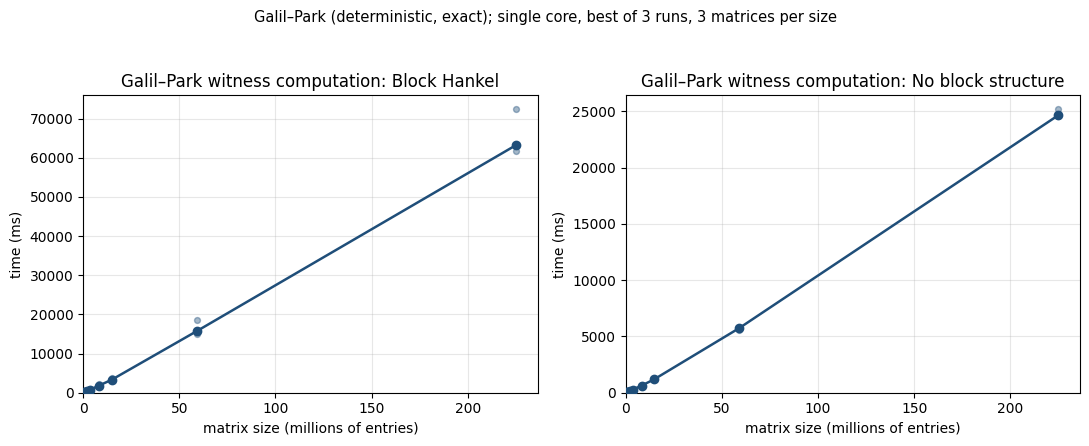

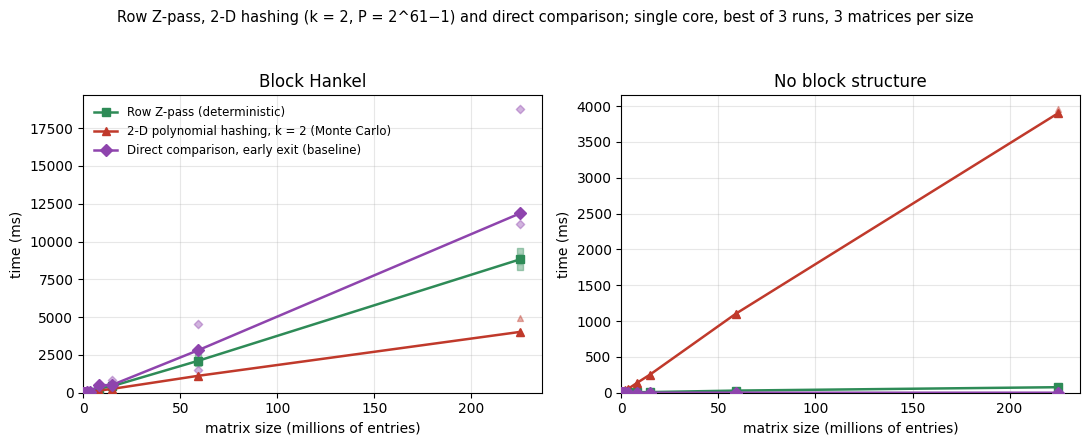

In [ ]:
import statistics, matplotlib.pyplot as plt
methods = [("gp_ms", "Galil–Park (deterministic)", "#1f4e79", "o"),
           ("zpass_ms", "Row Z-pass (deterministic)", "#2e8b57", "s"),
           ("hash_k2_ms", "2-D polynomial hashing, k = 2 (Monte Carlo)", "#c0392b", "^"),
           ("direct_ms", "Direct comparison, early exit (baseline)", "#8e44ad", "D")]
kinds = [("Yes", "Block Hankel"), ("No", "No block structure")] + ([("Near", "Near block Hankel")] if (df.block_hankel == "Near").any() else [])
sizes = sorted(df["size"].unique())

def draw(ax, kind, keep):
    sub = df[df.block_hankel == kind]
    for key, label, color, marker in keep:
        xs, meds = [], []
        for m in sizes:
            ts = list(sub[sub["size"] == m][key])
            if not ts: continue
            ax.scatter([m * m / 1e6] * len(ts), ts, s=18, color=color, marker=marker, alpha=0.4, zorder=3)
            xs.append(m * m / 1e6); meds.append(statistics.median(ts))
        ax.plot(xs, meds, color=color, marker=marker, markersize=6, linewidth=1.8, label=label, zorder=4)
    ax.set_xlabel("matrix size (millions of entries)"); ax.set_ylabel("time (ms)"); ax.grid(True, alpha=0.3)
    ax.set_xlim(left=0); ax.set_ylim(bottom=0)

# Figure A: Galil-Park alone
figA, axesA = plt.subplots(1, len(kinds), figsize=(5.5 * len(kinds), 4.5))
for ax, (kind, title) in zip(axesA, kinds):
    draw(ax, kind, methods[:1]); ax.set_title(f"Galil–Park witness computation: {title}")
figA.suptitle(f"Galil–Park (deterministic, exact); single core, best of {REPS} runs, 3 matrices per size", fontsize=10.5)
figA.tight_layout(rect=(0, 0, 1, 0.94)); figA.savefig("runtimes_galil_park.pdf"); figA.savefig("runtimes_galil_park.png", dpi=170)

# Figure B: the three fast methods
figB, axesB = plt.subplots(1, len(kinds), figsize=(5.5 * len(kinds), 4.5))
for ax, (kind, title) in zip(axesB, kinds):
    draw(ax, kind, methods[1:]); ax.set_title(title)
axesB[0].legend(loc="upper left", fontsize=8.5, frameon=False)
figB.suptitle(f"Row Z-pass, 2-D hashing (k = 2, P = 2^61−1) and direct comparison; single core, best of {REPS} runs, 3 matrices per size", fontsize=10.5)
figB.tight_layout(rect=(0, 0, 1, 0.94)); figB.savefig("runtimes_fast_methods.pdf"); figB.savefig("runtimes_fast_methods.png", dpi=170)
plt.show()

## 6. Ratios at the largest size

In [ ]:
big = df[df["size"] == max(sizes)].copy()
for key, label, *_ in methods: big[label] = big[key]
cols = [label for _, label, *_ in methods]
summary = big.groupby("block_hankel")[cols].median().T
summary["ratio to hashing"] = summary["Yes"] / summary.loc["2-D polynomial hashing, k = 2 (Monte Carlo)", "Yes"]
print(f"median time in ms at m = {max(sizes)}")
summary

median time in ms at m = 15000


block_hankel,No,Yes,ratio to hashing
Galil–Park (deterministic),24655.3,63186.6,15.707900
Row Z-pass (deterministic),77.1,8820.8,2.192811
"2-D polynomial hashing, k = 2 (Monte Carlo)",3902.0,4022.6,1.000000
"Direct comparison, early exit (baseline)",0.1,11863.1,2.949113


## 7. Download the results

In [ ]:
from google.colab import files
for f in [f"gpwc/{CSV}", "runtimes_galil_park.pdf", "runtimes_galil_park.png", "runtimes_fast_methods.pdf", "runtimes_fast_methods.png"]:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>